
# **FACULTAD DE INGENIERÍA - BIOINGENIERÍA**
# **Bioseñales y Sistemas**
## _**Segundo Proyecto - Clasificación de Datos BCI**_

*Maria José Rios Hurtado*

*Mónica Alejandra Hinestroza Chaparro*


### **1. CONSULTA**

**Consultar qué índices del EEG, adicionales a los realizados en el proyecto 1 basados en densidad espectral de potencia, mejoran la clasificación de estados en BCI. Citar las fuentes.**

**Escoger por lo menos tres índices que se puedan implementar en Python, se pueden usar librerías, explicar la medida y su uso en los datos del proyecto.**

<div align = "justify">

La densidad espectral de potencia (PSD) es uno de los métodos más empleados para caracterizar señales EEG en sistemas BCI basados en imaginería motora, pero su capacidad discriminativa tiene límites: opera por canal de forma independiente, asume cierta estacionariedad y no captura la distribución espacial ni la complejidad temporal de la actividad cortical. La literatura reciente identifica varios índices complementarios que mejoran la precisión de clasificación cuando se combinan o reemplazan a la PSD.


En el Proyecto 1 se caracterizó estados motores (reposo, movimiento real e imaginación) mediante la densidad espectral de potencia (PSD) en las bandas mu (8–13 Hz) y beta (13–30 Hz) sobre los canales C3 y C4. Si bien la PSD captura información sobre la energía por frecuencia, no refleja la distribución espacial de la actividad cortical, la dinámica temporal de la señal ni su complejidad no lineal. Los tres índices presentados a continuación complementan directamente los hallazgos de ese proyecto, son ampliamente respaldados por la literatura BCI y son implementables en Python.

</div>

<div align ="justify">

#### **Common Spatial Pattern (CSP)**

El CSP es una técnica de filtrado espacial que mejora la capacidad discriminativa de las señales EEG al ser particularmente útil para problemas de clasificación binaria, como distinguir entre imaginación de movimiento de mano derecha e izquierda. El CSP opera encontrando filtros espaciales que maximizan la varianza para una clase mientras la minimizan para la otra. Este principio lo hace directamente complementario a los análisis PSD del Proyecto 1, donde la lateralización entre C3 y C4 fue el hallazgo central: mientras la PSD cuantifica la potencia en cada canal por separado, el CSP encuentra la combinación lineal de todos los canales que maximiza esa diferencia inter-hemisférica de forma óptima.[1]

Durante la imaginería motora, los ritmos sensoriomotores se atenúan y luego se amplifican en corto tiempo, fenómeno conocido como desincronización/sincronización relacionada con eventos (ERD/ERS). Para extraer de forma óptima las características EEG que describen este fenómeno, el algoritmo CSP busca filtros espaciales que extraigan características espaciales discriminativas entre clases y es adoptado frecuentemente debido a su buen desempeño. Sin embargo, el desempeño del CSP depende fuertemente de la selección de bandas de frecuencia para la extracción del ritmo sensoriomotor. Por ello, variantes como Filter Bank CSP (FBCSP) aplican el método sobre múltiples bandas de frecuencia antes de seleccionar las más discriminativas. La implementación en Python se realiza con mne.decoding.CSP de la librería MNE. [2]

**- Funcionamiento Matemático:** El método calcula matrices de covarianza para cada clase (por ejemplo MI_R y MI_L) y resuelve un problema de autovalores generalizados:

$$\boxed{C_1 ​W = \lambda C_2 W}$$

donde:
 - C1 y C2 representan las matrices de covarianza de las dos clases
 - W corresponde a los filtros espaciales
 - $\lambda$ representa la capacidad discriminativa del filtro

Los filtros obtenidos generan nuevas señales espaciales donde las diferencias entre clases son más evidentes.

**- Interpretación Fisiológica:** En tareas de imaginación motora:

- El canal C3 suele activarse durante imaginación de movimiento de la mano derecha
- El canal C4 suele activarse durante imaginación de movimiento de la mano izquierda

El CSP amplifica estas diferencias espaciales, permitiendo identificar patrones de lateralización cerebral.

**- Implementación en Python:** Se utiliza la librería MNE

    from mne.decoding import CSP

    csp = CSP(n_components=4)
    X_csp = csp.fit_transform(X, y)

**- Ventajas:**

- Alta capacidad discriminativa
- Muy eficiente en BCI motoras
- Reduce dimensionalidad
- Mejora precisión de clasificadores

#### **Parámetros de Hjorth**

Los parámetros de Hjorth son características basadas en la varianza de las derivadas de la señal EEG. Las tres primeras derivadas de la señal dan lugar a las medidas de actividad (Activity), movilidad (Mobility) y complejidad (Complexity), que son los parámetros de Hjorth frecuentemente empleados en sistemas BCI. Estos tres descriptores operan enteramente en el dominio del tiempo, lo que los hace ortogonales a la PSD y muy rápidos de calcular. [3]

Activity mide la varianza cuadrática de la amplitud de la señal EEG en una ventana considerada. Mobility se define como la potencia promedio de la derivada normalizada de la señal EEG. Complexity representa la relación entre las movilidades, es decir, la movilidad de la primera derivada dividida entre la movilidad de la señal original. En términos fisiológicos, Activity es análoga a la potencia total integrada de la PSD, Mobility refleja desplazamientos en la frecuencia media dominante del ritmo mu o beta, y Complexity captura cuánto se aleja la señal de una oscilación sinusoidal pura, lo que aumenta cuando la corteza motora se activa y la señal se vuelve más irregular. [4]

Según resultados recientes, la actividad, movilidad y complejidad de segmentos EEG captados por los canales C3, Cz y C4, con y sin descomposición en sub-bandas, proporcionaron precisiones de clasificación confiables. El enfoque propuesto permitió discriminar tareas de movimiento ejecutado e imaginado, alcanzando una precisión promedio de clasificación de 89.7 ± 0.78%. En estudios comparativos de extracción de características para BCI, se ha reportado que la combinación de potencia de bandas, parámetros de Hjorth y coeficientes autorregresivos adaptativos presenta resultados consistentes en múltiples datasets EEG de BCI. Los parámetros de Hjorth se implementan directamente con NumPy a partir de las derivadas discretas de la señal, sin necesidad de librerías especializadas. [5]

#### **Energía y Entropía Wavelet (DWT)**

La Transformada Wavelet Discreta (DWT) ofrece una representación tiempo-frecuencia de resolución múltiple que supera a la PSD convencional en señales no estacionarias como el EEG. Se propone un método de extracción de características basado en la transformada wavelet discreta (DWT), la descomposición en modos empíricos (EMD) y la entropía aproximada. La señal EEG se descompone en una serie de señales de banda estrecha con la DWT, y la entropía aproximada de la señal reconstruida se obtiene como el vector de características correspondiente. [5]

De la DWT se derivan dos índices especialmente útiles para BCI. El primero es la energía relativa por sub-banda, que representa la fracción de la energía total contenida en cada nivel wavelet, siendo directamente comparable con la PSD integrada por banda del Proyecto 1 pero con mejor localización temporal. El segundo es la entropía de Shannon wavelet, que mide qué tan distribuida está la energía entre las sub-bandas: la entropía wavelet relativa y las características topológicas de la red de función cerebral pueden extraerse de forma conjunta, logrando una precisión de clasificación promedio superior al 90% en datasets públicos de BCI, lo que demuestra que estas características retienen información de la señal EEG de forma más efectiva y reducen la complejidad computacional. [5]

En el proceso de extracción de características es posible calcular energía, varianza y entropía de la transformada wavelet basadas en cinco sub-bandas de frecuencia EEG como características en el dominio tiempo-frecuencia, las cuales, combinadas con parámetros en el dominio del tiempo y del dominio de la frecuencia, permiten obtener los mejores resultados de selección en clasificaciones binarias y multiclase de imaginería motora. La implementación en Python se realiza con la librería PyWavelets (pywt), que permite la descomposición DWT con wavelets como db4, cuyos niveles se alinean con las bandas delta, theta, mu y beta para una frecuencia de muestreo de 160 Hz.[6]

#### **Coherencia**
El análisis de coherencia en el electroencefalograma (EEG) es una métrica neurofisiológica que evalúa la conectividad funcional y la sincronización entre distintas regiones del cerebro. Actúa como un índice que mide qué tan coordinadamente se comunican y oscilan dos áreas corticales a través de bandas de frecuencia específicas.

La coherencia es una medida de conectividad funcional que cuantifica el grado de sincronización entre dos señales EEG en una banda de frecuencia específica.Esta métrica permite evaluar cómo interactúan distintas regiones cerebrales durante tareas cognitivas o motoras.[7]

La coherencia toma valores entre:

0 → sin relación
1 → sincronización perfecta

**- Funcionamiento Matemático:** La coherencia entre dos señales x(t) e y(t) se define como:

$$\boxed{C_{xy}(f) = \frac{|P_{xy}(f)|^2}{P_{xx}(f) \cdot P_{yy}(f)}}$$

donde:

- P_xy(f): densidad espectral cruzada
- P_yy(f), P_xx(f) : densidades espectrales de potencia individuales

**- Interpretación Fisiológica:** En tareas motoras:

Aumentos de coherencia pueden indicar comunicación funcional entre áreas motoras
Disminuciones pueden reflejar especialización o lateralización de la actividad

La coherencia es especialmente útil para estudiar:

conectividad cortical
coordinación interhemisférica
organización funcional cerebral

**- Implementación en Python:** Se utilizan las librerias MNE y SciPy

    from scipy.signal import coherence

    f, coh = coherence(signal1, signal2, fs=fs)

**. Ventajas**

- Evalúa interacción entre regiones cerebrales
- Complementa análisis espectral
- Permite estudiar redes neuronales funcionales

#### **Entropía Espectral**

La entropía espectral en el Electroencefalograma (EEG) es una métrica de la teoría de la información que cuantifica la irregularidad o complejidad de las señales cerebrales. Se calcula a partir de la distribución de potencia en diferentes frecuencias; valores altos indican un cerebro despierto y activo, mientras que valores bajos reflejan regularidad y menor actividad.

La entropía espectral es una medida de complejidad basada en la distribución de energía de la señal EEG en el dominio de la frecuencia.Esta métrica cuantifica el grado de desorganización o irregularidad de la actividad cerebral.

Valores bajos → actividad más regular y organizada
Valores altos → actividad más compleja y distribuida

**- Fundamento Matemático:** La entropía espectral se calcula aplicando la entropía de Shannon sobre la PSD normalizada:

$$\boxed{H = -\sum_{i=1}^{N}p_i \log(p_i)}$$

donde:

- pi: representa la distribución normalizada de potencia espectral
- H: corresponde a la entropía espectral

**- Interpretación Fisiológica:** En EEG

Estados de reposo suelen presentar patrones más organizados
Tareas cognitivas o motoras incrementan la complejidad neuronal

La entropía espectral permite detectar cambios dinámicos en la organización cortical

**- Implementación en Python:** Se utilizan las librerias AntroPy y NumPy

    import antropy as ant

    entropy = ant.spectral_entropy(signal, sf=fs)

**. Ventajas**

- Captura complejidad neuronal
- Sensible a cambios cognitivos
- Complementa PSD y conectividad

#### **Selección de Índices**

De los índices consultados, se seleccionan la coherencia espectral y la entropía espectral como características escalares por canal y por época, las cuales se integrarán directamente en el DataFrame de análisis junto con la PSD del Proyecto 1. Estos dos índices son complementarios entre sí y con la PSD: mientras la PSD cuantifica la energía por banda en cada canal de forma independiente, la coherencia aporta información sobre la sincronización funcional entre regiones cerebrales, y la entropía espectral captura la complejidad e irregularidad de la actividad cortical. En conjunto, ofrecen una representación más completa de la dinámica cerebral durante las tareas de imaginería motora.

El CSP también se incluye en el proyecto, pero con un rol diferente al de los índices anteriores. A diferencia de la coherencia y la entropía, el CSP no produce valores escalares independientes por canal sino filtros espaciales que transforman conjuntamente todos los canales, y su ajuste requiere conocer las etiquetas de clase. Por estas razones, su lugar natural dentro del pipeline no es la extracción de características previa al DataFrame, sino la etapa de clasificación, donde se aplica como paso de preprocesamiento supervisado antes de los clasificadores, tal como es su uso estándar en la literatura BCI [1, 2]. Esta distinción se detalla en el Plan de Análisis.

</div>

### **2. PLAN DE ANÁLISIS**

**Con la información recolectada, del entregable 1 y del punto anterior, proponer una metodología de análisis que permita evidenciar la diferencia en ritmos cerebrales asociados a las condiciones de: reposo, imaginación de movimiento mano derecha, imaginación de movimiento mano izquierda.** 

Con base en el análisis realizado en el Proyecto 1 y en los índices adicionales consultados, se propone la siguiente metodología para caracterizar y comparar la actividad cerebral asociada a tres condiciones experimentales: reposo (REST), imaginación de movimiento de la mano derecha (MI_R) e imaginación de movimiento de la mano izquierda (MI_L).
La metodología sigue el flujo recomendado para el desarrollo de sistemas BCI [diapositivas de clase], que va desde la preparación de los datos hasta la evaluación del modelo de clasificación.

_**Etapa 1 — Preparación de datos y segmentación**_

Se reutiliza el pipeline de preprocesamiento del Proyecto 1 (filtro pasa-banda 1–40 Hz, filtro notch 60 Hz, rereferenciación CAR) aplicado sobre los canales C3, C4 y Cz. A partir de la señal continua preprocesada, se extraen épocas delimitadas por los marcadores de evento del dataset: T0 (reposo), T1 (MI_L) y T2 (MI_R), con una ventana de [0 s, 4 s] respecto al onset del estímulo. Esta segmentación ya fue implementada en el Proyecto 1 y se reutiliza directamente.

_**Etapa 2 — Extracción de características**_

Para cada época y cada canal de interés se calculan los siguientes índices, que conformarán las columnas del DataFrame de características:

a) Potencia espectral por bandas (PSD — mu y beta): heredada directamente del Proyecto 1. Calcula la potencia media en las bandas mu (8–13 Hz) y beta (13–30 Hz) usando el método de Welch. Produce un valor escalar por banda y por canal (ej. psd_mu_C3, psd_beta_C4).

b) Coherencia espectral (C3–C4, C3–Cz, C4–Cz): mide el grado de sincronización funcional entre pares de canales en las bandas mu y beta. Se calcula con scipy.signal.coherence y se promedia dentro de cada banda. Produce un valor escalar por par de canales y por banda (ej. coh_mu_C3C4, coh_beta_C3Cz).

c) Entropía espectral: cuantifica la complejidad de la señal midiendo qué tan distribuida está la energía espectral entre las frecuencias. Se calcula con antropy.spectral_entropy. Produce un valor escalar por canal (ej. ent_C3, ent_C4).

Todos estos índices se almacenan en un único DataFrame donde cada fila representa una época (un registro), con columnas para el sujeto, la condición y cada métrica calculada por canal.

_**Sobre el CSP:** el Common Spatial Pattern no se incluye como característica en el DataFrame porque su naturaleza es fundamentalmente diferente a los índices anteriores. El CSP no produce valores escalares independientes por canal, sino filtros espaciales que transforman conjuntamente todos los canales. Su entrenamiento requiere las etiquetas de clase, lo que lo hace parte del pipeline de clasificación (no de extracción de características previa). El CSP se aplicará por tanto en la Etapa 5, como paso de preprocesamiento supervisado antes del clasificador, tal como se hace habitualmente en la literatura BCI [1, 2]._

_**Etapa 3 — Organización del DataFrame y preparación para clasificación**_

El DataFrame resultante tendrá la siguiente estructura, consistente con el formato solicitado en el enunciado:

| Registro | Tarea | psd_mu_C3 | psd_beta_C4 | coh_mu_C3C4 | ent_C3 | ... |
|----------|-------|-----------|-------------|-------------|--------|-----|
| S001_R04_epoch0 | MI_R | ... | ... | ... | ... | ... |

Una vez construido el DataFrame se realizan los siguientes pasos de preparación antes de alimentar los clasificadores:

- _Codificación de etiquetas:_ las etiquetas textuales (REST, MI_R, MI_L) se convierten a valores numéricos (0, 1, 2).
- _Normalización de características:_ todas las columnas de características se normalizan al mismo rango para evitar que índices de mayor magnitud dominen el entrenamiento. La etiqueta no se normaliza.
- _Análisis de correlación:_ se calcula la matriz de correlación entre características. Correlaciones superiores a 0.85 en valor absoluto son señal de redundancia que puede perjudicar el modelo; en ese caso se elimina una de las características correlacionadas.
- _Balance de clases:_ se verifica que las tres condiciones tengan representación proporcional en el conjunto de datos, dado que los clasificadores son sensibles al desbalance de clases.
- _División train/test:_ se separa el 80% de los datos para entrenamiento y el 20% para evaluación, con random_state fijo para garantizar reproducibilidad.

_**Etapa 4 — Análisis estadístico descriptivo e inferencial**_

Sobre el DataFrame de características se realizan dos tipos de análisis:

a) _Estadística descriptiva:_ se calculan media, mediana, desviación estándar e IQR para cada índice por condición. Las visualizaciones se seleccionan según el tipo de comparación: boxplots para comparar distribuciones entre condiciones, mapas de calor para la matriz de correlación entre características, y matrices de conectividad para los valores de coherencia entre pares de canales.

b) _Pruebas de hipótesis:_ se plantean hipótesis formales para los índices que visualmente muestren mayor diferencia entre condiciones. La elección entre prueba paramétrica o no paramétrica depende del resultado de la prueba de normalidad (Shapiro-Wilk). Para comparaciones entre más de dos grupos se aplicará ANOVA o Kruskal-Wallis; para comparaciones entre pares de condiciones, t-test o Wilcoxon. En todos los casos:

- **H₀:** no existen diferencias significativas entre las condiciones comparadas en el índice evaluado.
- **H₁:** existen diferencias significativas entre las condiciones comparadas en el índice evaluado.

El umbral de significancia es α = 0.05.

_**Etapa 5 — Clasificación**_

La clasificación se realiza usando únicamente los índices que hayan mostrado mayor diferencia estadística entre condiciones en la Etapa 4. El pipeline de clasificación sigue el esquema enseñado en clase:

1. _Preprocesamiento con CSP:_ antes de alimentar el clasificador, se aplica CSP sobre las épocas para extraer componentes espaciales discriminativos entre clases. Esto se realiza con mne.decoding.CSP dentro del pipeline de entrenamiento, garantizando que el CSP se ajuste únicamente con datos de entrenamiento en cada fold para evitar fuga de información.

2. _Estrategia de validación cruzada (k-fold):_ se utiliza K-Fold con k=10 para estimar el desempeño del modelo de forma robusta, evitando tanto overfitting como underfitting. El score final reportado es el promedio de las k iteraciones.

3. _Arquitecturas de clasificación:_ se entrenan y comparan al menos tres configuraciones de red neuronal MLP (MLPClassifier) con diferentes números de capas y neuronas, evaluando su desempeño con el classification_report tanto en entrenamiento como en evaluación.

4. _Modelos adicionales:_ se implementan y discuten una Máquina de Soporte Vectorial (SVM) y Extreme Gradient Boosting (XGBoost), comparando su desempeño con las redes MLP.

5. _Métricas de evaluación:_ para cada modelo se reportan la matriz de confusión (normalizada y sin normalizar), accuracy, precisión, recall y F1-score. Se discuten los falsos positivos y negativos en el contexto clínico de un sistema BCI.

### **3. PROGRAMACIÓN**

**a. Crear una función que reciba una señal de EEG procesada y permita obtener la densidad espectral de potencia y los índices adicionales consultados en un conjunto de canales de interés.**

**b. Crear una rutina que aplique sobre todos los archivos de la base de datos la rutina de procesamiento y la de extracción de caracteríticas y almacene los resultados en un dataframe donde se pueda discriminar nombre sujeto, la condición evaluada y la métrica calculada.**

In [42]:
# Importaciones y configuración global

!pip install mne antropy xgboost

%matplotlib inline

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import mne
import antropy as ant

from scipy.signal import coherence
from scipy import stats
from scipy.stats import shapiro, kruskal, f_oneway, mannwhitneyu

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                             classification_report)

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')  # silencia MNE sin suprimir errores reales


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: C:\Users\mrios\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [43]:
# Configuración global

# Ruta a la carpeta raíz donde están las subcarpetas S001, S002, ...
RUTA_DATOS = Path(r"C:\Users\mrios\Desktop\Universidad\Semestre VII\Bioseñales\files")

# Runs de imaginería motora en el dataset PhysioNet EEGBCI:
#   Run 4, 8, 12 → T0 = REST, T1 = MI_L (img izq), T2 = MI_R (img der)
RUNS_MI = [4, 8, 12]

# Canales de interés (sistema 10-20, sobre la corteza sensoriomotora)
CANALES = ['C3', 'C4', 'Cz']

# Duración de cada época en segundos (igual que Proyecto 1)
DUR_EPOCA = 4.0

# Mapeo etiqueta textual → numérica para los clasificadores
ETIQUETAS = {'REST': 0, 'MI_L': 1, 'MI_R': 2}

# Verificación rápida de que la ruta existe
assert RUTA_DATOS.exists(), f"Ruta no encontrada: {RUTA_DATOS}"
sujetos_encontrados = sorted([d for d in RUTA_DATOS.iterdir() if d.is_dir()])
print(f"Sujetos encontrados: {len(sujetos_encontrados)}")
print("Primeros 5:", [s.name for s in sujetos_encontrados[:5]])

Sujetos encontrados: 109
Primeros 5: ['S001', 'S002', 'S003', 'S004', 'S005']


In [44]:
# Funciones heredadas del Proyecto 1

def cargar_eeg(ruta_edf):
    """
    Carga un archivo .edf del dataset PhysioNet EEGBCI,
    estandariza los nombres de canal al sistema 10-20
    y asigna el montaje estándar.

    Parámetros
    ----------
    ruta_edf : str o Path
        Ruta al archivo .edf.

    Retorna
    -------
    raw : mne.io.Raw
        Señal cruda lista para preprocesar.
    """
    raw = mne.io.read_raw_edf(str(ruta_edf), preload=True, verbose=False)
    mne.datasets.eegbci.standardize(raw)          # Fp1., AF3. → Fp1, AF3
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, verbose=False)
    return raw


def procesar_eeg(raw):
    """
    Pipeline de preprocesamiento del Proyecto 1 (no modifica el objeto original):
      1. Filtro pasa-banda 1–40 Hz  → elimina deriva DC y artefactos de alta frecuencia
      2. Filtro notch 60 Hz         → elimina la interferencia de la red eléctrica (EE.UU.)
      3. Rereferenciación CAR        → reduce artefactos comunes a todos los electrodos

    Retorna
    -------
    raw_proc : mne.io.Raw
        Copia de la señal con el preprocesamiento aplicado.
    """
    raw_proc = (raw.copy()
                .filter(l_freq=1.0, h_freq=40.0, verbose=False)
                .notch_filter(freqs=60.0, verbose=False)
                .set_eeg_reference('average', verbose=False))
    return raw_proc


def get_condicion(anotacion):
    """
    Traduce la anotación del evento (T0, T1, T2) a una etiqueta legible.

    En los runs de imaginería motora del dataset PhysioNet EEGBCI:
      T0 → Reposo        (REST)
      T1 → Imagen izq.   (MI_L)
      T2 → Imagen der.   (MI_R)

    Parámetros
    ----------
    anotacion : str
        Cadena del tipo 'T0', 'T1' o 'T2'.

    Retorna
    -------
    str : 'REST' | 'MI_L' | 'MI_R' | 'UNKNOWN'
    """
    mapa = {'T0': 'REST', 'T1': 'MI_L', 'T2': 'MI_R'}
    return mapa.get(anotacion, 'UNKNOWN')

In [45]:
# Función de extracción de características=

def extraer_caracteristicas(data_epoca, sfreq, canales_usados):
    """
    Calcula cuatro grupos de índices sobre una época EEG preprocesada.

    Índices calculados
    ------------------
    1. PSD por bandas mu y beta  (heredada del Proyecto 1)
       Método de Welch con ventana Hamming, n_fft=256, solapamiento 50%.
       Cuantifica la energía espectral en las bandas motoras relevantes.
       Referencia: Welch, 1967; usado en Proyecto 1.

    2. Coherencia espectral por pares de canales  (C3-C4, C3-Cz, C4-Cz)
       scipy.signal.coherence → Cxy(f) ∈ [0,1], promediada por banda.
       Mide sincronización funcional entre regiones motoras.
       No requiere conversión de unidades (medida normalizada).
       Referencia: Atienza et al., 2000 [7].

    3. Entropía espectral por canal
       antropy.spectral_entropy con normalize=True → valores en [0,1].
       Valores bajos: ritmo mu dominante (reposo).
       Valores altos: energía distribuida por ERD/ERS (tarea motora).
       Referencia: Ji et al., 2019 [5].

    4. Parámetros de Hjorth por canal  (Activity, Mobility, Complexity)
       Calculados en dominio temporal con derivadas discretas (np.diff).
       Complementan la PSD al ser ortogonales al dominio frecuencial.
       Referencia: Elahi et al., 2023 [3]; Garcia-Laencina et al., 2014 [4].

    Parámetros
    ----------
    data_epoca : np.ndarray, shape (n_canales, n_muestras)
        Datos de la época en µV. Filas en el mismo orden que canales_usados.
    sfreq : float
        Frecuencia de muestreo en Hz.
    canales_usados : list of str
        Nombres de los canales. Ej: ['C3', 'C4', 'Cz'].

    Retorna
    -------
    resultado : dict
        Diccionario plano con todas las características. Claves:
          mu_C3, mu_C4, mu_Cz           → PSD banda mu   (µV²/Hz)
          beta_C3, beta_C4, beta_Cz     → PSD banda beta (µV²/Hz)
          coh_mu_C3C4, coh_mu_C3Cz, ... → coherencia mu  [0,1]
          coh_beta_C3C4, ...            → coherencia beta [0,1]
          ent_C3, ent_C4, ent_Cz        → entropía espectral [0,1]
          hjorth_act_C3, ...            → actividad de Hjorth (µV²)
          hjorth_mob_C3, ...            → movilidad de Hjorth
          hjorth_comp_C3, ...           → complejidad de Hjorth
    """

    resultado = {}
    n_muestras = data_epoca.shape[1]

    # n_fft no puede superar n_muestras; mínimo razonable = 64 puntos
    n_fft = min(256, n_muestras)

    # 1. PSD POR BANDAS (mu: 8-13 Hz, beta: 13-30 Hz)
    # psd_array_welch espera la señal en Voltios → dividimos por 1e6.
    # El resultado viene en V²/Hz → multiplicamos por 1e12 para volver
    # a µV²/Hz, misma unidad que el Proyecto 1.
    # Operación vectorizada: psd_uv2 tiene forma (n_canales, n_freqs).
    # .mean(axis=1) promedia sobre las frecuencias de la banda → escalar
    # por canal, sin ningún bucle explícito sobre canales.

    bandas = {
        'mu'  : (8.0,  13.0),
        'beta': (13.0, 30.0),
    }

    psd_v2, freqs = mne.time_frequency.psd_array_welch(
        data_epoca * 1e-6,   # µV → V
        sfreq     = sfreq,
        fmin      = 1.0,
        fmax      = 40.0,
        n_fft     = n_fft,
        n_overlap = n_fft // 2,
        window    = 'hamming',
        verbose   = False
    )
    psd_uv2 = psd_v2 * 1e12  # V²/Hz → µV²/Hz

    for nombre_banda, (fmin_b, fmax_b) in bandas.items():
        mask = (freqs >= fmin_b) & (freqs <= fmax_b)
        if not np.any(mask):
            for ch in canales_usados:
                resultado[f'{nombre_banda}_{ch}'] = np.nan
            continue
        # psd_uv2[:, mask] → (n_canales, n_bins_banda)
        # .mean(axis=1)    → (n_canales,) — vectorizado, sin for de canales
        potencias = psd_uv2[:, mask].mean(axis=1)
        for i, ch in enumerate(canales_usados):
            resultado[f'{nombre_banda}_{ch}'] = potencias[i]

    # 2. COHERENCIA ESPECTRAL POR PARES DE CANALES
    # scipy.signal.coherence devuelve Cxy(f) ∈ [0,1] para cada frecuencia.
    # Se promedia dentro de cada banda → escalar por (par, banda).
    # La coherencia es una medida normalizada (ratio de espectros), por
    # lo tanto NO depende de la escala absoluta de la señal: se usa
    # data_epoca en µV directamente, sin conversión.

    idx_ch = {ch: i for i, ch in enumerate(canales_usados)}

    pares = [(a, b) for a, b in [('C3','C4'), ('C3','Cz'), ('C4','Cz')]
             if a in idx_ch and b in idx_ch]

    for ch_a, ch_b in pares:
        f_coh, Cxy = coherence(
            data_epoca[idx_ch[ch_a]],
            data_epoca[idx_ch[ch_b]],
            fs      = sfreq,
            nperseg = n_fft
        )
        for nombre_banda, (fmin_b, fmax_b) in bandas.items():
            mask = (f_coh >= fmin_b) & (f_coh <= fmax_b)
            clave = f'coh_{nombre_banda}_{ch_a}{ch_b}'
            resultado[clave] = Cxy[mask].mean() if np.any(mask) else np.nan

    # 3. ENTROPÍA ESPECTRAL POR CANAL
    # antropy.spectral_entropy aplica la entropía de Shannon sobre la PSD
    # normalizada: H = -Σ p_i · log(p_i), donde p_i es la fracción de
    # potencia en cada bin de frecuencia.
    # normalize=True → H queda entre 0 y 1, comparable entre sujetos.
    #
    # Interpretación fisiológica en este dataset:
    #   REST  → ritmo mu (~10 Hz) dominante → energía concentrada → H bajo
    #   MI_L/R → ERD atenúa el mu, la energía se redistribuye → H sube

    for i, ch in enumerate(canales_usados):
        resultado[f'ent_{ch}'] = ant.spectral_entropy(
            data_epoca[i],
            sf        = sfreq,
            method    = 'welch',
            normalize = True
        )

    # 4. PARÁMETROS DE HJORTH POR CANAL
    # Los parámetros de Hjorth se calculan a partir de la señal y sus
    # derivadas discretas (np.diff), operando completamente en el dominio
    # del tiempo. Son ortogonales a la PSD y muy rápidos de calcular.
    #
    # Activity   = Var(x)          → potencia total de la señal (≈ PSD integrada)
    # Mobility   = √(Var(x') / Var(x))   → frecuencia media dominante
    # Complexity = Mobility(x') / Mobility(x) → cuán lejos está la señal
    #              de una sinusoide pura; sube cuando la corteza se activa
    #              y la señal se vuelve más irregular.
    #
    # Referencia: Elahi et al., 2023; Garcia-Laencina et al., 2014.
    #
    # Implementación vectorizada: np.var opera sobre el eje de muestras
    # (axis=1) para todos los canales simultáneamente.

    # Derivada discreta de primer orden: x'[n] ≈ x[n+1] - x[n]
    d1 = np.diff(data_epoca, n=1, axis=1)   # primera derivada
    d2 = np.diff(data_epoca, n=2, axis=1)   # segunda derivada

    var_x  = np.var(data_epoca, axis=1)          # (n_canales,)
    var_d1 = np.var(d1,         axis=1)
    var_d2 = np.var(d2,         axis=1)

    # Añadir epsilon para evitar división por cero en señales planas
    eps = 1e-12

    activity   = var_x
    mobility   = np.sqrt(var_d1 / (var_x  + eps))
    mob_d1     = np.sqrt(var_d2 / (var_d1 + eps))
    complexity = mob_d1 / (mobility + eps)

    for i, ch in enumerate(canales_usados):
        resultado[f'hjorth_act_{ch}']  = activity[i]
        resultado[f'hjorth_mob_{ch}']  = mobility[i]
        resultado[f'hjorth_comp_{ch}'] = complexity[i]

    return resultado

In [46]:
# Pipeline masivo y construcción del DataFrame

registros = []   # cada elemento será un dict con todas las features de una época

for carpeta_sujeto in sorted(RUTA_DATOS.iterdir()):

    # Saltar cualquier cosa que no sea una carpeta de sujeto (ej. archivos sueltos)
    if not carpeta_sujeto.is_dir():
        continue

    nombre_sujeto = carpeta_sujeto.name   # ej. 'S001'

    for num_run in RUNS_MI:

        # Construir el nombre del archivo según la convención PhysioNet
        # ej. S001R04.edf
        nombre_archivo = f"{nombre_sujeto}R{num_run:02d}.edf"
        ruta_edf = carpeta_sujeto / nombre_archivo

        # Si el archivo no existe para este sujeto, saltarlo sin detener el pipeline
        if not ruta_edf.exists():
            print(f"  [AVISO] No encontrado: {nombre_archivo}")
            continue

        try:
            # ── Paso 1: carga ──────────────────────────────────────────
            raw = cargar_eeg(ruta_edf)

            # ── Paso 2: preprocesamiento ───────────────────────────────
            raw_proc = procesar_eeg(raw)

            # ── Paso 3: extracción de épocas ───────────────────────────
            # mne.events_from_annotations convierte las anotaciones T0/T1/T2
            # del archivo EDF en un array de eventos MNE estándar.
            eventos, event_id = mne.events_from_annotations(raw_proc, verbose=False)

            # tmax=DUR_EPOCA - 1/sfreq → la época tiene exactamente DUR_EPOCA
            # segundos sin solapar con el siguiente onset.
            # baseline=None → no se resta ninguna línea de base, igual que
            # en el Proyecto 1 (ya se aplicó CAR globalmente).
            sfreq = raw_proc.info['sfreq']

            epochs = mne.Epochs(
                raw_proc,
                eventos,
                event_id  = event_id,
                tmin      = 0.0,
                tmax      = DUR_EPOCA - 1.0 / sfreq,
                baseline  = None,
                preload   = True,
                verbose   = False
            )

            # Quedarse solo con los canales de interés que existan en este archivo
            canales_disponibles = [ch for ch in CANALES if ch in epochs.ch_names]
            if len(canales_disponibles) < 2:
                # Con menos de 2 canales no se puede calcular coherencia
                print(f"  [AVISO] Canales insuficientes en {nombre_archivo}")
                continue
            epochs.pick(canales_disponibles, verbose=False)

            # ── Paso 4: extracción de características por época ────────
            for nombre_evento, codigo_evento in event_id.items():

                # Traducir T0/T1/T2 → REST/MI_L/MI_R
                condicion = get_condicion(nombre_evento)
                if condicion == 'UNKNOWN':
                    continue

                # Épocas de esta condición: shape (n_epocas, n_canales, n_muestras)
                epocas_condicion = epochs[nombre_evento].get_data()

                for idx_epoca, data_epoca in enumerate(epocas_condicion):

                    # data_epoca: shape (n_canales, n_muestras) en µV
                    features = extraer_caracteristicas(
                        data_epoca,
                        sfreq,
                        canales_disponibles
                    )

                    # ── Paso 5: agregar metadatos ──────────────────────
                    # 'registro' es el identificador único de la época:
                    # incluye sujeto, run y número de época dentro del run
                    # para poder rastrear cada fila del DataFrame.
                    features['registro'] = f"{nombre_sujeto}_R{num_run:02d}_{condicion}_e{idx_epoca:03d}"
                    features['sujeto']   = nombre_sujeto
                    features['run']      = num_run
                    features['tarea']    = condicion

                    # Columna 'label': versión numérica de 'tarea'
                    # necesaria para los clasificadores (sklearn espera números)
                    # ETIQUETAS = {'REST': 0, 'MI_L': 1, 'MI_R': 2}
                    features['label']    = ETIQUETAS[condicion]

                    registros.append(features)

        except Exception as e:
            print(f"  [ERROR] {nombre_archivo}: {e}")
            continue

    print(f"✓ {nombre_sujeto} procesado — épocas acumuladas: {len(registros)}")

print(f"\nTotal de épocas procesadas: {len(registros)}")

✓ S001 procesado — épocas acumuladas: 90
✓ S002 procesado — épocas acumuladas: 180
✓ S003 procesado — épocas acumuladas: 270
✓ S004 procesado — épocas acumuladas: 360
✓ S005 procesado — épocas acumuladas: 450
✓ S006 procesado — épocas acumuladas: 540
✓ S007 procesado — épocas acumuladas: 630
✓ S008 procesado — épocas acumuladas: 720
✓ S009 procesado — épocas acumuladas: 810
✓ S010 procesado — épocas acumuladas: 900
✓ S011 procesado — épocas acumuladas: 990
✓ S012 procesado — épocas acumuladas: 1080
✓ S013 procesado — épocas acumuladas: 1170
✓ S014 procesado — épocas acumuladas: 1260
✓ S015 procesado — épocas acumuladas: 1350
✓ S016 procesado — épocas acumuladas: 1440
✓ S017 procesado — épocas acumuladas: 1530
✓ S018 procesado — épocas acumuladas: 1620
✓ S019 procesado — épocas acumuladas: 1710
✓ S020 procesado — épocas acumuladas: 1800
✓ S021 procesado — épocas acumuladas: 1890
✓ S022 procesado — épocas acumuladas: 1980
✓ S023 procesado — épocas acumuladas: 2070
✓ S024 procesado — époc

#### **DATA FRAME FINAL CON TODAS LAS CARACTERÍSTICAS Y ETIQUETAS**

In [47]:
# Construcción y verificación del DataFrame

df = pd.DataFrame(registros)

# Reordenar columnas: metadatos primero, características después
# Esto hace el DataFrame más legible al inspeccionarlo
cols_meta     = ['registro', 'sujeto', 'run', 'tarea', 'label']
cols_features = [c for c in df.columns if c not in cols_meta]
df = df[cols_meta + cols_features]

print("Shape del DataFrame:", df.shape)
print(f"\nÉpocas por condición:")
print(df['tarea'].value_counts())
print(f"\nNúmero de sujetos: {df['sujeto'].nunique()}")
print(f"\nColumnas de características ({len(cols_features)}):")
print(cols_features)
print(f"\nValores NaN por columna:")
print(df[cols_features].isna().sum()[df[cols_features].isna().sum() > 0])

df.head()

Shape del DataFrame: (9835, 29)

Épocas por condición:
tarea
REST    4918
MI_L    2479
MI_R    2438
Name: count, dtype: int64

Número de sujetos: 109

Columnas de características (24):
['mu_C3', 'mu_C4', 'mu_Cz', 'beta_C3', 'beta_C4', 'beta_Cz', 'coh_mu_C3C4', 'coh_beta_C3C4', 'coh_mu_C3Cz', 'coh_beta_C3Cz', 'coh_mu_C4Cz', 'coh_beta_C4Cz', 'ent_C3', 'ent_C4', 'ent_Cz', 'hjorth_act_C3', 'hjorth_mob_C3', 'hjorth_comp_C3', 'hjorth_act_C4', 'hjorth_mob_C4', 'hjorth_comp_C4', 'hjorth_act_Cz', 'hjorth_mob_Cz', 'hjorth_comp_Cz']

Valores NaN por columna:
Series([], dtype: int64)


,registro,sujeto,run,tarea,label,mu_C3,mu_C4,mu_Cz,beta_C3,beta_C4,...,ent_Cz,hjorth_act_C3,hjorth_mob_C3,hjorth_comp_C3,hjorth_act_C4,hjorth_mob_C4,hjorth_comp_C4,hjorth_act_Cz,hjorth_mob_Cz,hjorth_comp_Cz
0,S001_R04_REST_e000,S001,4,REST,0,3.070198e-12,7.706645e-12,8.945171e-12,2.677936e-12,2.735355e-12,...,0.722987,2.249911e-10,0.580184,1.974015,3.096552e-10,0.445789,2.320650,2.960911e-10,0.523832,2.100802
1,S001_R04_REST_e001,S001,4,REST,0,4.236736e-12,4.202317e-12,4.779347e-12,2.342497e-12,1.968304e-12,...,0.693915,2.511695e-10,0.551796,2.005853,1.810907e-10,0.514146,2.025174,2.683632e-10,0.430979,2.433136
2,S001_R04_REST_e002,S001,4,REST,0,9.757747e-12,9.990099e-12,6.480408e-12,2.014309e-12,2.702462e-12,...,0.585635,3.100004e-10,0.464452,2.332772,3.780278e-10,0.401420,2.507346,4.797131e-10,0.348252,2.989865
3,S001_R04_REST_e003,S001,4,REST,0,6.940686e-12,8.609434e-12,4.560111e-12,2.742811e-12,2.293919e-12,...,0.721704,2.367724e-10,0.549948,1.870584,2.356283e-10,0.471551,2.106635,2.321357e-10,0.472082,2.170182
4,S001_R04_REST_e004,S001,4,REST,0,6.488558e-12,5.128647e-12,7.834325e-12,2.012367e-12,2.347031e-12,...,0.598222,2.311626e-10,0.492719,2.147694,2.851694e-10,0.450294,2.302759,3.992851e-10,0.380120,2.719228


In [48]:
df.to_csv("caracteristicas_bci.csv", index=False)
print("DataFrame guardado en caracteristicas_bci.csv")

DataFrame guardado en caracteristicas_bci.csv


In [49]:
# ── Separación X / y ──────────────────────────────────────────────────
# X: solo las columnas de características numéricas (sin metadatos)
# y: etiqueta numérica (0=REST, 1=MI_L, 2=MI_R)
#
# IMPORTANTE: esta separación se hace DESPUÉS de guardar el CSV completo
# con los metadatos, para que el archivo guardado conserve toda la info.

X = df[cols_features].values   # numpy array (n_epocas, n_features)
y = df['label'].values          # numpy array (n_epocas,)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Clases únicas en y: {np.unique(y, return_counts=True)}")

X shape: (9835, 24)
y shape: (9835,)
Clases únicas en y: (array([0, 1, 2]), array([4918, 2479, 2438]))


### **4. ANÁLISIS DE RESULTADOS**

**a. Discusión de las diferencias en las condiciones para los diferentes índices usando las gráficas obtenidas usando estadística descriptiva. Seleccione el tipo de representación que mejor le permita describir la información (ver el enlace recomendado) y use comparaciones válidas.**


In [50]:
# 6a.1 — Tabla resumen de estadística descriptiva

PALETA = {'REST': '#4C72B0', 'MI_L': '#DD8452', 'MI_R': '#55A868'}
ORDEN  = ['REST', 'MI_L', 'MI_R']

# Función IQR nombrada para que el MultiIndex la reconozca bien
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

iqr.__name__ = 'IQR'   # nombre que aparecerá en el índice

resumen = (df.groupby('tarea')[cols_features]
             .agg(['mean', 'median', 'std', iqr])
             .round(4))

resumen.columns = resumen.columns.set_levels(
    ['Media', 'Mediana', 'Std', 'IQR'],
    level=1
)

print("Estadística descriptiva por condición:")
print(resumen.T)

Estadística descriptiva por condición:
tarea                     MI_L    MI_R    REST
mu_C3          Media    0.0000  0.0000  0.0000
               Mediana  0.0000  0.0000  0.0000
               Std      0.0000  0.0000  0.0000
               IQR      0.0000  0.0000  0.0000
mu_C4          Media    0.0000  0.0000  0.0000
...                        ...     ...     ...
hjorth_mob_Cz  IQR      0.1658  0.1540  0.1554
hjorth_comp_Cz Media    2.2128  2.2162  2.2071
               Mediana  2.1440  2.1291  2.1390
               Std      0.5765  0.5719  0.5341
               IQR      0.6743  0.6707  0.6531

[96 rows x 3 columns]


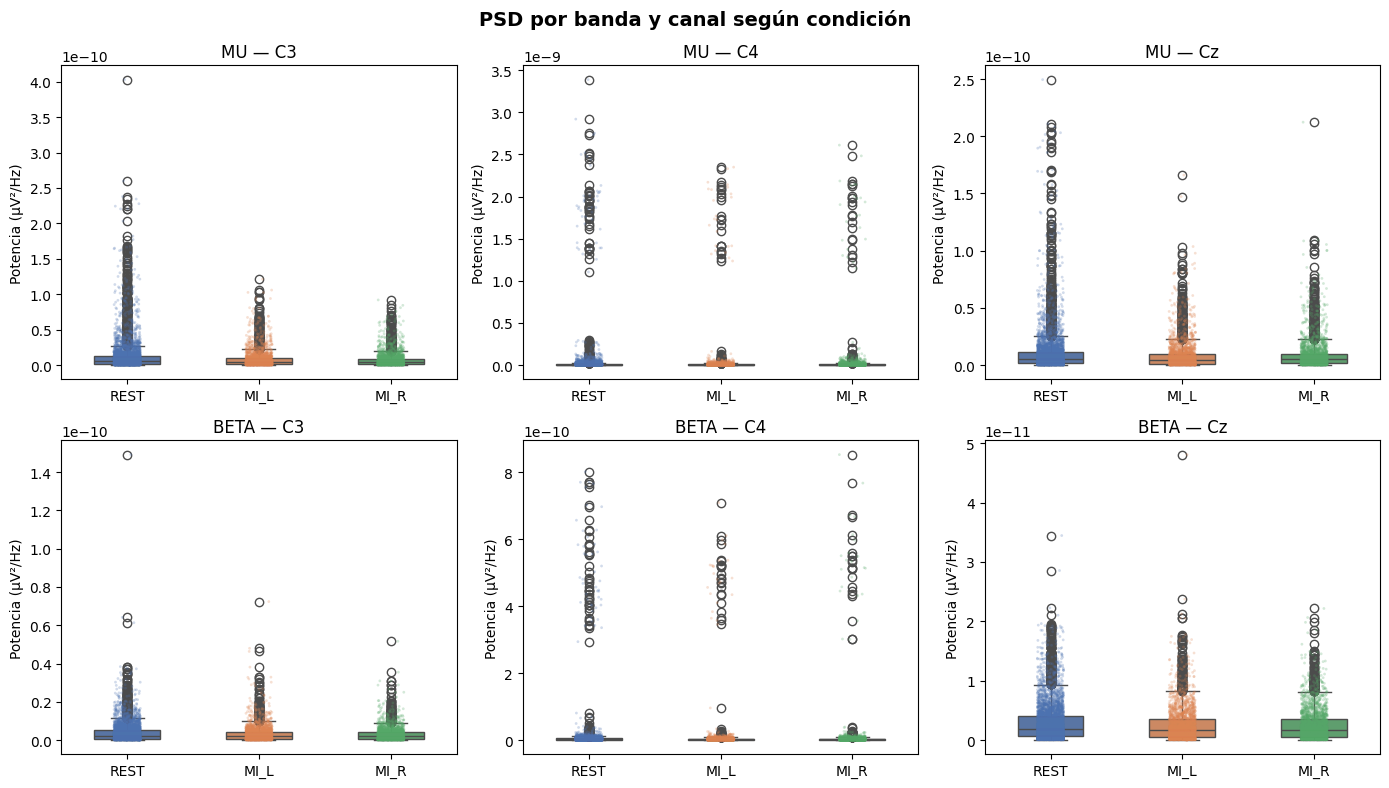

In [51]:
# 6a.2 Boxplots — PSD banda mu y beta 
# Justificación de la elección del gráfico: el boxplot muestra
# simultáneamente la mediana, el IQR y los valores atípicos, lo que
# permite comparar distribuciones entre condiciones sin asumir normalidad.
# Referencia de selección: https://www.data-to-viz.com (enlace del enunciado)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('PSD por banda y canal según condición', fontsize=14, fontweight='bold')

for fila, banda in enumerate(['mu', 'beta']):
    for col, canal in enumerate(CANALES):
        col_nombre = f'{banda}_{canal}'
        if col_nombre not in df.columns:
            continue
        ax = axes[fila, col]
        sns.boxplot(
            data    = df,
            x       = 'tarea',
            y       = col_nombre,
            order   = ORDEN,
            palette = PALETA,
            width   = 0.5,
            ax      = ax
        )
        # Superponer los puntos individuales para ver la densidad real
        # alpha bajo para no saturar cuando hay muchas épocas
        sns.stripplot(
            data    = df,
            x       = 'tarea',
            y       = col_nombre,
            order   = ORDEN,
            palette = PALETA,
            size    = 2,
            alpha   = 0.25,
            jitter  = True,
            ax      = ax
        )
        ax.set_title(f'{banda.upper()} — {canal}')
        ax.set_xlabel('')
        ax.set_ylabel('Potencia (µV²/Hz)')

plt.tight_layout()
plt.savefig('boxplot_psd.png', dpi=150, bbox_inches='tight')
plt.show()

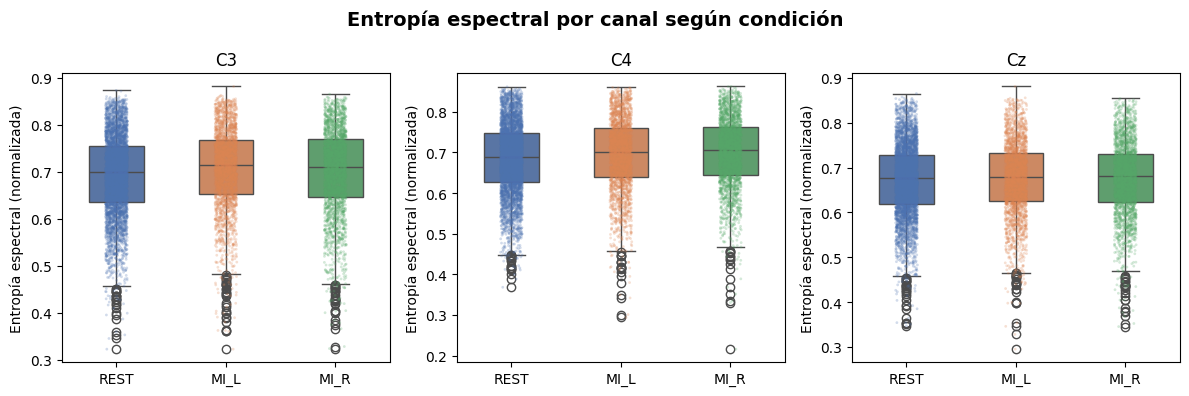

In [52]:
# 6a.3 Boxplots — Entropía espectral 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Entropía espectral por canal según condición',
             fontsize=14, fontweight='bold')

for ax, canal in zip(axes, CANALES):
    col_nombre = f'ent_{canal}'
    if col_nombre not in df.columns:
        continue
    sns.boxplot(
        data=df, x='tarea', y=col_nombre,
        order=ORDEN, palette=PALETA, width=0.5, ax=ax
    )
    sns.stripplot(
        data=df, x='tarea', y=col_nombre,
        order=ORDEN, palette=PALETA,
        size=2, alpha=0.25, jitter=True, ax=ax
    )
    ax.set_title(canal)
    ax.set_xlabel('')
    ax.set_ylabel('Entropía espectral (normalizada)')

plt.tight_layout()
plt.savefig('boxplot_entropia.png', dpi=150, bbox_inches='tight')
plt.show()

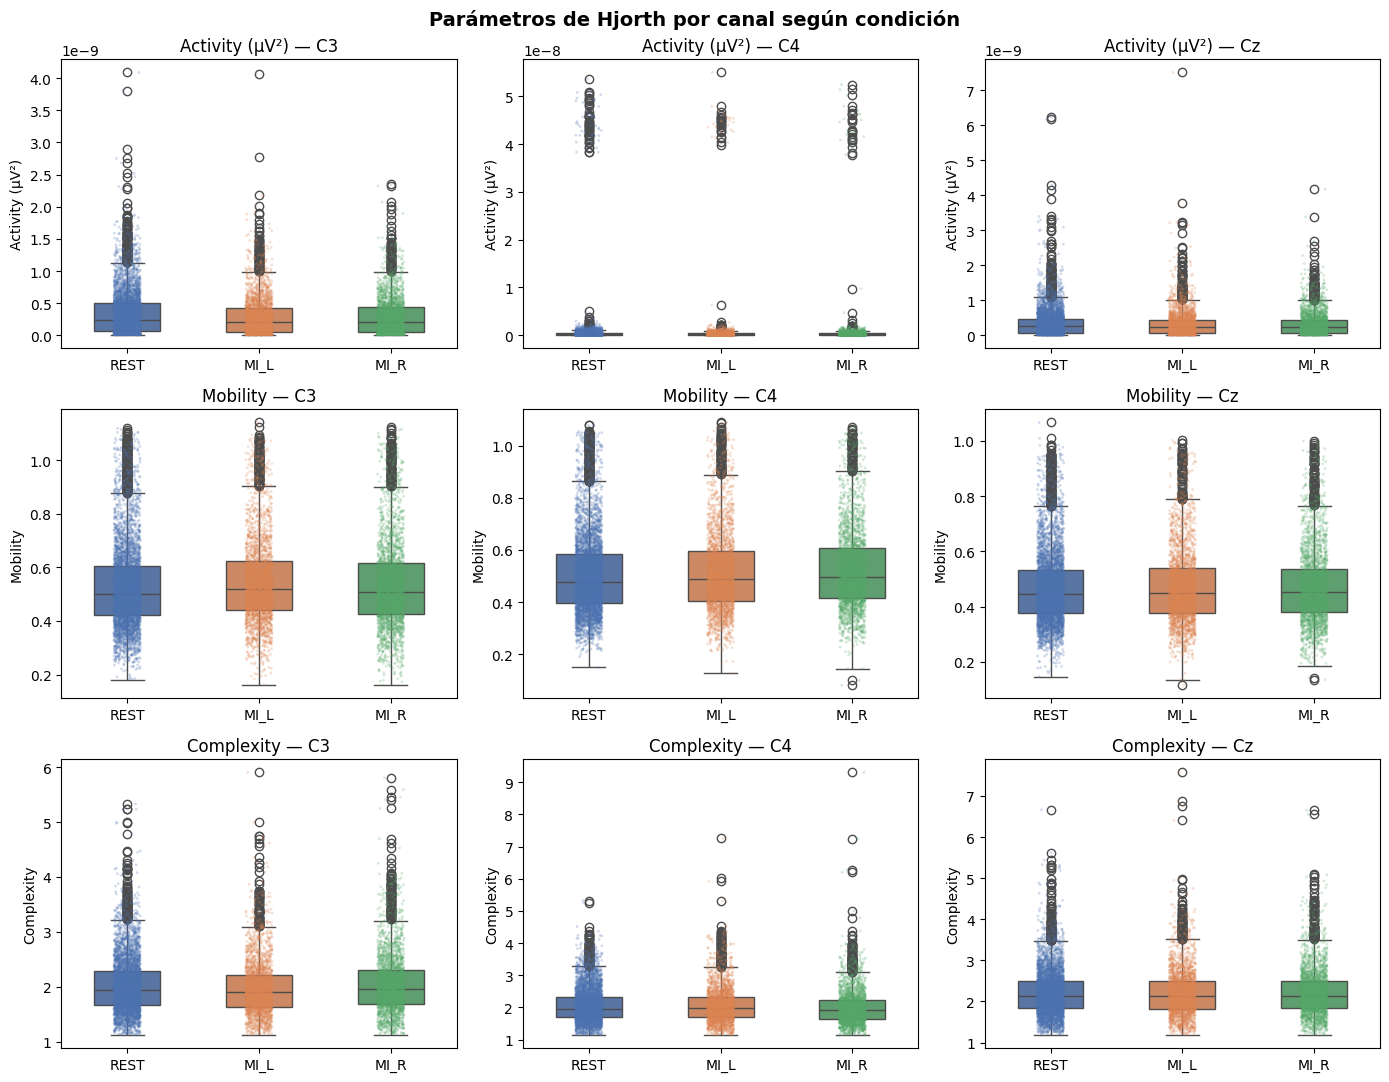

In [53]:
# 6a.4 Boxplots — Parámetros de Hjorth 

parametros_hjorth = ['act', 'mob', 'comp']
nombres_hjorth    = ['Activity (µV²)', 'Mobility', 'Complexity']

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
fig.suptitle('Parámetros de Hjorth por canal según condición',
             fontsize=14, fontweight='bold')

for fila, (param, nombre) in enumerate(zip(parametros_hjorth, nombres_hjorth)):
    for col, canal in enumerate(CANALES):
        col_nombre = f'hjorth_{param}_{canal}'
        if col_nombre not in df.columns:
            continue
        ax = axes[fila, col]
        sns.boxplot(
            data=df, x='tarea', y=col_nombre,
            order=ORDEN, palette=PALETA, width=0.5, ax=ax
        )
        sns.stripplot(
            data=df, x='tarea', y=col_nombre,
            order=ORDEN, palette=PALETA,
            size=2, alpha=0.25, jitter=True, ax=ax
        )
        ax.set_title(f'{nombre} — {canal}')
        ax.set_xlabel('')
        ax.set_ylabel(nombre)

plt.tight_layout()
plt.savefig('boxplot_hjorth.png', dpi=150, bbox_inches='tight')
plt.show()

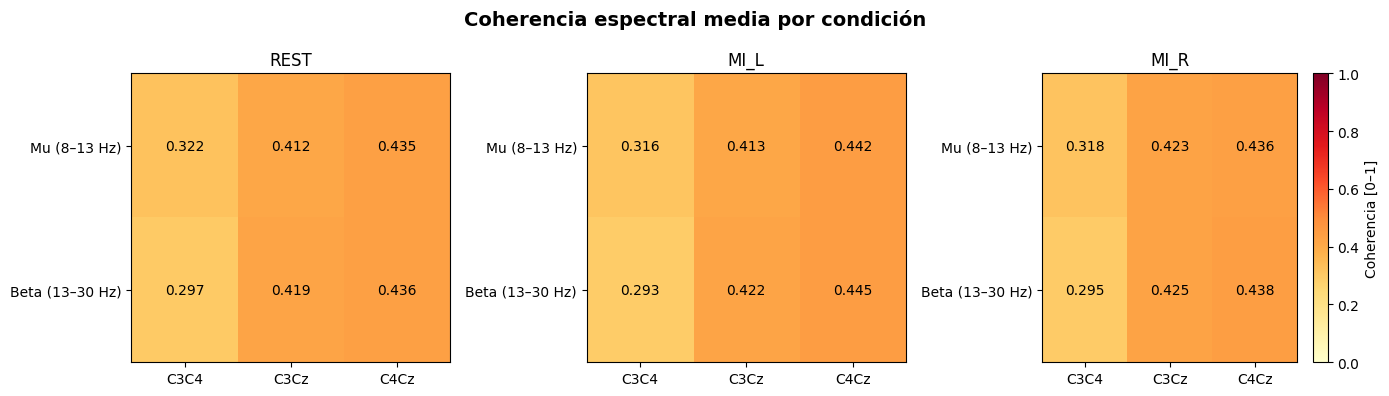

In [54]:
# 6a.5 Heatmap de coherencia 
# La coherencia es una medida de conectividad entre pares de canales.
# Un heatmap permite ver simultáneamente los tres pares y las dos bandas
# para cada condición, facilitando comparaciones visuales rápidas.

pares_coh  = ['C3C4', 'C3Cz', 'C4Cz']
fig, axes  = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Coherencia espectral media por condición',
             fontsize=14, fontweight='bold')

for ax, condicion in zip(axes, ORDEN):
    subset = df[df['tarea'] == condicion]

    # Construir matriz 2 bandas × 3 pares con los valores medios
    matriz = np.array([
        [subset[f'coh_{banda}_{par}'].mean() for par in pares_coh]
        for banda in ['mu', 'beta']
    ])

    im = ax.imshow(matriz, vmin=0, vmax=1, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(pares_coh)))
    ax.set_xticklabels(pares_coh)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Mu (8–13 Hz)', 'Beta (13–30 Hz)'])
    ax.set_title(condicion)

    # Anotar cada celda con el valor numérico
    for i in range(2):
        for j in range(3):
            ax.text(j, i, f'{matriz[i, j]:.3f}',
                    ha='center', va='center', fontsize=10,
                    color='black' if matriz[i, j] < 0.6 else 'white')

plt.colorbar(im, ax=axes[-1], label='Coherencia [0–1]')
plt.tight_layout()
plt.savefig('heatmap_coherencia.png', dpi=150, bbox_inches='tight')
plt.show()

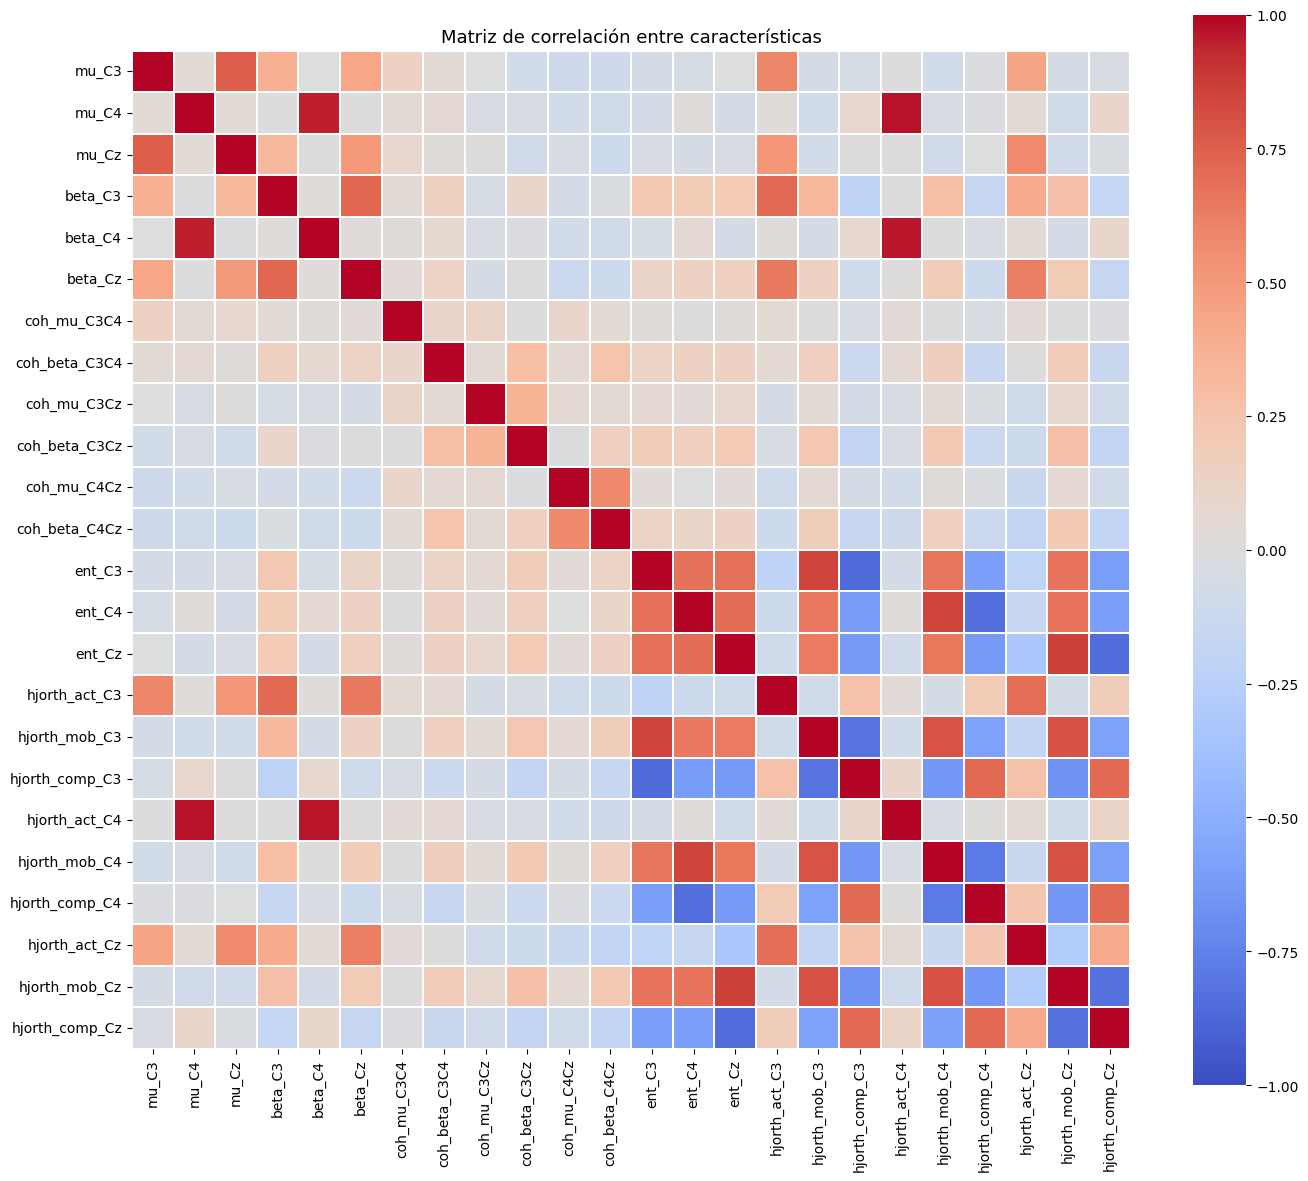

Pares con |correlación| > 0.85 (posible redundancia):
  beta_C4  ↔  mu_C4  →  r = 0.952
  beta_C4  ↔  hjorth_act_C4  →  r = 0.968
  ent_C3  ↔  hjorth_comp_C3  →  r = -0.858
  ent_C4  ↔  hjorth_mob_C4  →  r = 0.851
  ent_Cz  ↔  hjorth_mob_Cz  →  r = 0.862
  ent_Cz  ↔  hjorth_comp_Cz  →  r = -0.851
  hjorth_act_C4  ↔  mu_C4  →  r = 0.973


In [55]:
# 6a.6 Matriz de correlación entre características 
# Permite detectar redundancia entre índices antes de clasificar.
# Correlaciones > 0.85 en valor absoluto sugieren eliminar una de las
# dos características (como se mencionó en el Plan de Análisis).

fig, ax = plt.subplots(figsize=(14, 12))

corr = df[cols_features].corr()

sns.heatmap(
    corr,
    ax         = ax,
    cmap       = 'coolwarm',
    center     = 0,
    vmin       = -1, vmax = 1,
    annot      = False,   # con muchas features los números se solapan
    linewidths = 0.3,
    square     = True
)
ax.set_title('Matriz de correlación entre características', fontsize=13)
plt.tight_layout()
plt.savefig('correlacion_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Identificar pares altamente correlacionados (|r| > 0.85)
corr_abs = corr.abs()
pares_correlacionados = [
    (col, row, corr.loc[row, col])
    for col in corr.columns
    for row in corr.index
    if row > col and corr_abs.loc[row, col] > 0.85
]

if pares_correlacionados:
    print("Pares con |correlación| > 0.85 (posible redundancia):")
    for c1, c2, r in pares_correlacionados:
        print(f"  {c1}  ↔  {c2}  →  r = {r:.3f}")
else:
    print("No se encontraron pares altamente correlacionados.")

### **Análisis y justificación de los índices seleccionados**

**Densidad Espectral de Potencia (PSD)**
<div align ="justify">

Se analizaron principalmente las bandas mu (8-13 Hz) y beta (13-30 Hz), debido a que están directamente relacionadas con la planificación y ejecución del movimiento. Durante tareas de imaginación motora se espera observar una disminución de potencia (ERD) en estas bandas sobre las regiones motoras contralaterales al movimiento imaginado.

Los resultados descriptivos obtenidos muestran una disminución de la potencia media tanto en la banda mu como en la banda beta durante las condiciones de imaginación motora respecto al estado de reposo. En el canal C3, por ejemplo, la potencia media en la banda mu disminuyó de aproximadamente 10.45 µV²/Hz en reposo a valores entre 7.14 y 8.07 µV²/Hz durante las tareas de imaginación motora, mientras que en la banda beta se observó una reducción de 3.79 µV²/Hz en reposo a valores cercanos a 3.0 µV²/Hz durante las tareas activas. Este comportamiento es consistente con los mecanismos neurofisiológicos descritos para la imaginación motora, donde la activación de las redes motoras provoca una reducción de la sincronización neuronal en las frecuencias mu y beta.

En conjunto, estos resultados indican que la densidad espectral de potencia es una característica muy discriminante, ya que refleja directamente las modificaciones de los ritmos sensorimotores asociadas a la imaginación de movimiento. Por esta razón, la PSD en las bandas mu y beta fue seleccionada como una de las principales variables de entrada para los algoritmos de clasificación implementados posteriormente.
</div>


**Coherencia espectral**
<div align ="justify">
La coherencia espectral fue seleccionada debido a que permite evaluar la conectividad funcional entre diferentes regiones cerebrales. A diferencia de la PSD, que analiza la actividad local de un electrodo, la coherencia mide el grado de sincronización entre pares de canales.

En el contexto de la imaginación motora, se espera que las conexiones entre C3, Cz y C4 se modifiquen durante la planificación y simulación mental del movimiento. Por esta razón, la coherencia aporta información complementaria a la potencia espectral y puede mejorar la capacidad discriminativa de los clasificadores.

Las medidas de coherencia presentan diferencias relativamente pequeñas entre las tres condiciones evaluadas. Los valores promedio se mantienen entre 0.29 y 0.44 para todos los pares de canales analizados.La coherencia interhemisférica C3-C4 en banda mu presenta una ligera disminución durante las tareas de imaginación motora respecto al reposo:

- REST = 0.3224
- MI_L = 0.3164
- MI_R = 0.3183

Los resultados obtenidos indican que la coherencia espectral presentó variaciones moderadas entre las condiciones evaluadas. Aunque las diferencias observadas fueron menores que las encontradas en las medidas de potencia espectral, se identificaron ligeros cambios en la sincronización funcional entre las regiones motoras durante la imaginación de movimiento. En particular, se observó una reducción de la coherencia mu entre C3 y C4 durante las tareas de imaginación motora, lo que podría reflejar procesos de especialización funcional y lateralización cortical. Sin embargo, la magnitud de las diferencias sugiere que la coherencia por sí sola posee una capacidad limitada para discriminar entre las condiciones experimentales.
</div>



**Entropía espectral** 
<div align ="justify">
se empleó para cuantificar la complejidad de la actividad cerebral. Esta medida describe cómo se distribuye la energía de la señal en el dominio de la frecuencia.

Valores bajos indican que la energía está concentrada en pocas frecuencias dominantes, situación típica de estados de reposo. Por el contrario, valores altos reflejan una distribución más uniforme de la energía, característica de procesos cognitivos activos como la imaginación motora.

Por esta razón, la entropía espectral constituye una característica complementaria que permite capturar información que no puede ser observada únicamente mediante la potencia espectral.

para el canal C3:

- REST = 0.6931
- MI_L = 0.7074
- MI_R = 0.6999

Para el canal C4:

- REST = 0.6844
- MI_L = 0.6943
- MI_R = 0.6997

Para el canal Cz:

- REST = 0.6720
- MI_L = 0.6761
- MI_R = 0.6760

En los tres canales la entropía es mayor durante imaginación motora que durante reposo.Se observa una tendencia consistente a incrementar durante las condiciones de imaginación motora respecto al estado de reposo. Este comportamiento fue observado en los tres canales analizados (C3, C4 y Cz), siendo más evidente en los electrodos localizados sobre la corteza motora. El incremento de la entropía indica una distribución más uniforme de la energía espectral y una mayor complejidad de la actividad neuronal durante la ejecución mental de la tarea. Estos resultados son coherentes con los mecanismos fisiológicos de la imaginación motora, donde se produce una reorganización temporal de los ritmos cerebrales asociados al movimiento. Debido a la consistencia de las diferencias observadas, la entropía espectral constituye una característica prometedora para la clasificación automática de estados en sistemas BCI.
</div>

Entre los índices evaluados, la densidad espectral de potencia fue la característica que mostró las diferencias más marcadas entre las condiciones experimentales, especialmente en la banda mu. La entropía espectral también presentó una capacidad discriminativa importante al reflejar cambios en la complejidad de la actividad cerebral durante la imaginación motora. Por el contrario, la coherencia espectral mostró variaciones más sutiles entre condiciones, por lo que su principal utilidad radica en complementar la información aportada por la potencia espectral y la entropía. En conjunto, los tres índices proporcionan una representación más completa de la actividad cerebral y justifican su utilización como variables de entrada para los modelos de clasificación propuestos.

**b. Planteamiento de las hipótesis nulas y alternativas, selección del tipo de prueba (paramétrica o no paramétrica) y discusión de los resultados.**

### **Hipótesis**

<div align = "justify">

- **PSD**

    H0: No existen diferencias significativas en la potencia espectral de las bandas mu y beta entre las condiciones de reposo (REST), imaginación de movimiento de la mano izquierda (MI_L) e imaginación de movimiento de la mano derecha (MI_R)

    H1: Existen diferencias significativas en la potencia espectral de las bandas mu y/o beta entre las condiciones de reposo, MI_L y MI_R

- **Coherencia**

    H0: No existen diferencias significativas en la coherencia espectral entre los canales motores (C3-C4, C3-Cz y C4-Cz) entre las condiciones REST, MI_L y MI_R

    H1: Existen diferencias significativas en la coherencia espectral entre los canales motores según la condición experimental

- **Entropía**

    H0: No existen diferencias significativas en la entropía espectral entre las condiciones REST, MI_L y MI_R

    H1: Existen diferencias significativas en la entropía espectral entre las condiciones REST, MI_L y MI_R.

</div>

In [1]:
# 6b — Pruebas de hipótesis

ALPHA = 0.05

resultados_test = []   # almacena los resultados de cada prueba

grupos_por_condicion = {
    cond: df[df['tarea'] == cond] for cond in ORDEN
}

for feature in cols_features:

    grupos = [grupos_por_condicion[cond][feature].dropna().values
              for cond in ORDEN]

    # ── Paso 1: prueba de normalidad Shapiro-Wilk ─────────────────────
    # Shapiro-Wilk es la prueba de normalidad más potente para muestras
    # pequeñas y medianas. Si p > α → no se rechaza H₀ de normalidad.
    # Con muestras muy grandes casi siempre rechaza normalidad aunque la
    # distribución sea aproximadamente normal; en ese caso Kruskal-Wallis
    # es igualmente válida y más conservadora.
    normal = all(shapiro(g).pvalue > ALPHA for g in grupos if len(g) >= 3)

    # ── Paso 2: prueba global entre las tres condiciones ──────────────
    if normal:
        stat, p_global = f_oneway(*grupos)
        prueba_global  = 'ANOVA'
    else:
        stat, p_global = kruskal(*grupos)
        prueba_global  = 'Kruskal-Wallis'

    significativo = p_global < ALPHA

    # ── Paso 3: comparaciones post-hoc por pares (solo si es sig.) ────
    # Se usa Mann-Whitney U (no paramétrica) para todos los pares
    # independientemente del resultado de Shapiro, porque es más robusta
    # cuando hay diferente varianza entre grupos.
    # Corrección de Bonferroni: α_corregido = α / n_comparaciones
    pares_condiciones = [('REST','MI_L'), ('REST','MI_R'), ('MI_L','MI_R')]
    n_comparaciones   = len(pares_condiciones) * len(cols_features)
    alpha_bonf        = ALPHA / n_comparaciones

    posthoc = {}
    if significativo:
        for c1, c2 in pares_condiciones:
            g1 = grupos_por_condicion[c1][feature].dropna().values
            g2 = grupos_por_condicion[c2][feature].dropna().values
            _, p_par = mannwhitneyu(g1, g2, alternative='two-sided')
            posthoc[f'{c1}_vs_{c2}'] = p_par

    resultados_test.append({
        'feature'      : feature,
        'normalidad'   : normal,
        'prueba'       : prueba_global,
        'estadistico'  : round(stat, 4),
        'p_valor'      : round(p_global, 6),
        'significativo': significativo,
        **{k: round(v, 6) for k, v in posthoc.items()}
    })

df_tests = pd.DataFrame(resultados_test).set_index('feature')
print(df_tests.to_string())


KeyboardInterrupt



In [57]:
# Resumen visual de los resultados ─────────────────────────────────
# Ranking de características por p-valor (de menor a mayor).
# Las características con menor p-valor son las más discriminativas
# y serán las candidatas para la etapa de clasificación.

df_sig = df_tests[df_tests['significativo']].sort_values('p_valor')

print(f"\nCaracterísticas significativas ({len(df_sig)} de {len(cols_features)}):")
print(df_sig[['prueba', 'p_valor']].to_string())

# Las N mejores características para clasificación
N_MEJORES = 8
features_seleccionadas = df_sig.head(N_MEJORES).index.tolist()
print(f"\nTop {N_MEJORES} características seleccionadas para clasificación:")
for i, f in enumerate(features_seleccionadas, 1):
    print(f"  {i}. {f}  (p = {df_sig.loc[f, 'p_valor']:.2e})")


Características significativas (20 de 24):
                        prueba   p_valor
feature                                 
mu_C3           Kruskal-Wallis  0.000000
mu_C4           Kruskal-Wallis  0.000000
mu_Cz           Kruskal-Wallis  0.000000
beta_C3         Kruskal-Wallis  0.000000
beta_C4         Kruskal-Wallis  0.000000
hjorth_act_C3   Kruskal-Wallis  0.000000
ent_C3          Kruskal-Wallis  0.000000
ent_C4          Kruskal-Wallis  0.000000
hjorth_mob_C4   Kruskal-Wallis  0.000000
hjorth_comp_C4  Kruskal-Wallis  0.000000
hjorth_act_C4   Kruskal-Wallis  0.000000
hjorth_mob_C3   Kruskal-Wallis  0.000002
beta_Cz         Kruskal-Wallis  0.000003
hjorth_comp_C3  Kruskal-Wallis  0.000003
coh_beta_C3C4   Kruskal-Wallis  0.000087
hjorth_act_Cz   Kruskal-Wallis  0.000305
coh_beta_C4Cz   Kruskal-Wallis  0.000823
coh_mu_C3Cz     Kruskal-Wallis  0.001425
ent_Cz          Kruskal-Wallis  0.020569
coh_mu_C4Cz     Kruskal-Wallis  0.034680

Top 8 características seleccionadas para clasificació

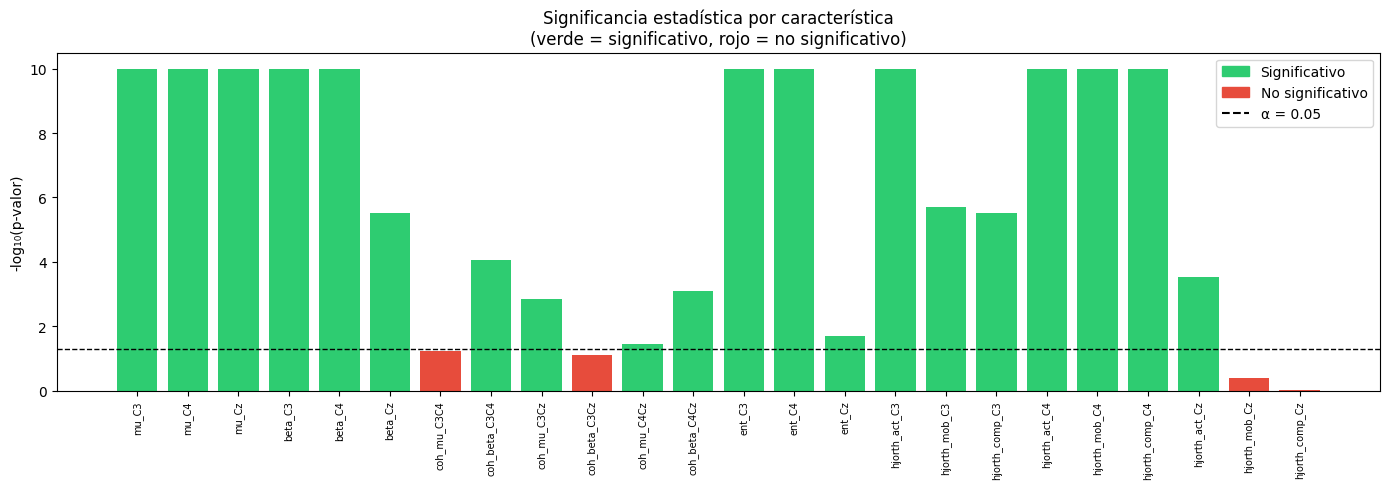

In [58]:
# Gráfico de p-valores ───────────────────────────────────────────────
# Visualización del -log10(p) para todas las características.
# La línea roja marca el umbral α = 0.05.
# Las barras que la superan corresponden a diferencias significativas.

fig, ax = plt.subplots(figsize=(14, 5))

p_vals   = df_tests['p_valor'].clip(lower=1e-10)   # evitar log(0)
log_p    = -np.log10(p_vals)
colores  = ['#2ecc71' if s else '#e74c3c'
            for s in df_tests['significativo']]

ax.bar(range(len(log_p)), log_p, color=colores, edgecolor='none')
ax.axhline(-np.log10(ALPHA), color='black', linestyle='--', linewidth=1,
           label=f'α = {ALPHA}')
ax.set_xticks(range(len(log_p)))
ax.set_xticklabels(df_tests.index, rotation=90, fontsize=7)
ax.set_ylabel('-log₁₀(p-valor)')
ax.set_title('Significancia estadística por característica\n'
             '(verde = significativo, rojo = no significativo)')

parche_sig   = mpatches.Patch(color='#2ecc71', label='Significativo')
parche_nosig = mpatches.Patch(color='#e74c3c', label='No significativo')
ax.legend(handles=[parche_sig, parche_nosig, 
                   plt.Line2D([0],[0], color='black', linestyle='--',
                              label=f'α = {ALPHA}')])

plt.tight_layout()
plt.savefig('pvalores_features.png', dpi=150, bbox_inches='tight')
plt.show()

### **Hipótesis**

<div align = "justify">

- **PSD**

    H0: No existen diferencias significativas en la potencia espectral de las bandas mu y beta entre las condiciones de reposo (REST), imaginación de movimiento de la mano izquierda (MI_L) e imaginación de movimiento de la mano derecha (MI_R)

    H1: Existen diferencias significativas en la potencia espectral de las bandas mu y/o beta entre las condiciones de reposo, MI_L y MI_R

Los resultados descriptivos mostraron una disminución consistente de la potencia en las bandas mu y beta durante las tareas de imaginación motora respecto al estado de reposo.Este comportamiento es coherente con el fenómeno de ERD (Event Related Desynchronization) descrito en la literatura de imaginación motora.

Las gráficas tipo boxplot y los mapas de calor muestran que la potencia durante reposo es sistemáticamente mayor que durante las tareas activas. Los resultados descriptivos aportan evidencia a favor de la hipótesis alternativa H1 y sugieren que la PSD es capaz de discriminar entre estados de reposo e imaginación motora.

- **Coherencia**

    H0: No existen diferencias significativas en la coherencia espectral entre los canales motores (C3-C4, C3-Cz y C4-Cz) entre las condiciones REST, MI_L y MI_R

    H1: Existen diferencias significativas en la coherencia espectral entre los canales motores según la condición experimental

Los resultados descriptivos muestran variaciones leves de la coherencia entre condiciones. Aunque estas diferencias sugieren posibles cambios en la organización funcional de la red motora, la magnitud observada es considerablemente menor que la encontrada para la PSD. Por ello, la coherencia parece actuar como una característica complementaria más que como un marcador principal de discriminación entre estados.


- **Entropía**

    H0: No existen diferencias significativas en la entropía espectral entre las condiciones REST, MI_L y MI_R

    H1: Existen diferencias significativas en la entropía espectral entre las condiciones REST, MI_L y MI_R.

Los resultados muestran un incremento consistente de la entropía espectral durante las tareas de imaginación motora respecto al reposo. Este comportamiento sugiere una mayor complejidad de la actividad neuronal cuando el sujeto realiza la simulación mental del movimiento. Aunque las diferencias observadas son menores que las encontradas para la PSD, presentan una tendencia estable en los tres canales estudiados, indicando que la entropía puede constituir una característica útil para complementar los procesos de clasificación.

</div>

### **5. CLASIFICACIÓN**

### **Selección de Características para clasificación**
 Las variables con menor p-valor son mejores candidatas

###  **Validación K-Fold**

<div align="justify">
Se implementó validación cruzada k-fold con el fin de obtener una estimación más robusta del desempeño de los clasificadores. Esta técnica divide el conjunto de datos en k subconjuntos de tamaño similar. En cada iteración uno de los subconjuntos se utiliza para validación y los restantes para entrenamiento. El proceso se repite hasta que todos los subconjuntos han sido utilizados como conjunto de prueba. Finalmente se calcula el promedio de las métricas obtenidas. Esta metodología reduce la dependencia de una única partición entrenamiento-prueba y permite evaluar mejor la capacidad de generalización del modelo.
</div>

In [60]:
# Preparación de datos para clasificación

# Se usan SOLO las características seleccionadas en el bloque 6b
# (las que mostraron mayor diferencia estadística entre condiciones)

X_sel = df[features_seleccionadas].values   # (n_epocas, n_features_sel)
y     = df['label'].values                  # (n_epocas,)

# Escalado estándar: media=0, std=1 por característica
# Necesario para MLP y SVM, que son sensibles a la magnitud de las features
# XGBoost no lo requiere pero no le hace daño
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)

# Estrategia de validación cruzada
# StratifiedKFold mantiene la proporción de REST/MI_L/MI_R en cada fold,
# lo cual es importante porque con datos desbalanceados un KFold normal
# podría generar folds sin ejemplos de alguna clase.
# k=10 es el estándar en la literatura BCI para estimaciones robustas.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f"Features seleccionadas: {len(features_seleccionadas)}")
print(f"X_scaled shape: {X_scaled.shape}")
print(f"Distribución de clases: {dict(zip(*np.unique(y, return_counts=True)))}")

Features seleccionadas: 8
X_scaled shape: (9835, 8)
Distribución de clases: {np.int64(0): np.int64(4918), np.int64(1): np.int64(2479), np.int64(2): np.int64(2438)}


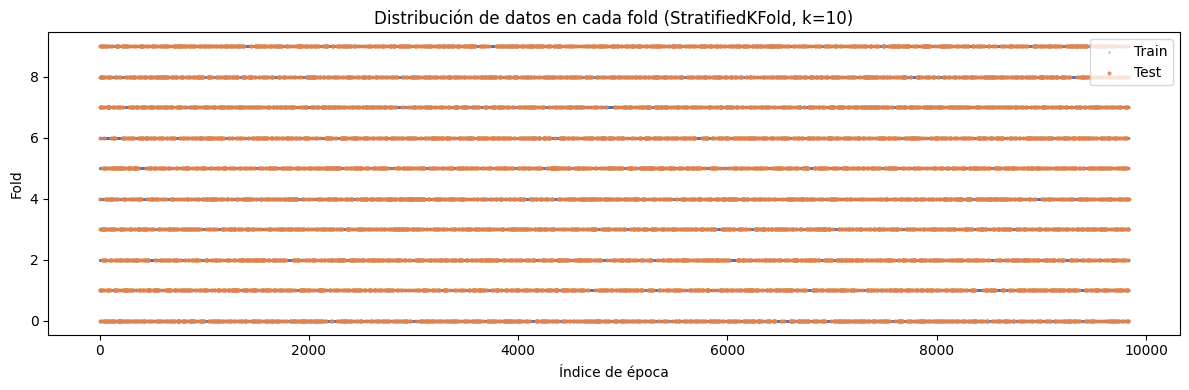

In [61]:
# 7b — Discusión de la estrategia K-Fold

# K-Fold divide el dataset en k subconjuntos (folds) del mismo tamaño.
# En cada iteración:
#   - k-1 folds se usan para entrenar el modelo
#   - 1 fold se usa para evaluarlo
# Esto se repite k veces, rotando qué fold es el de evaluación.
# El score final es el promedio de las k iteraciones.
#
# Ventajas frente a una sola división train/test:
#   - Usa todos los datos tanto para entrenar como para evaluar
#   - La estimación del desempeño tiene menor varianza
#   - Detecta overfitting: si train >> test en todos los folds, hay sobreajuste
#
# Por qué Stratified:
#   Con 3 clases (REST, MI_L, MI_R) un KFold estándar podría generar folds
#   donde alguna clase tenga muy pocos o ningún ejemplo, produciendo
#   estimaciones sesgadas. StratifiedKFold garantiza que cada fold tenga
#   la misma proporción de clases que el dataset completo.
#
# Referencia: Blankertz et al., 2008 [1]; práctica estándar en BCI.

# Visualización de cómo se dividen los folds
fig, ax = plt.subplots(figsize=(12, 4))

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_scaled, y)):
    ax.scatter(train_idx, [fold_idx] * len(train_idx),
               c='#4C72B0', s=1, alpha=0.3, label='Train' if fold_idx == 0 else '')
    ax.scatter(test_idx,  [fold_idx] * len(test_idx),
               c='#DD8452', s=4, alpha=0.8, label='Test'  if fold_idx == 0 else '')

ax.set_xlabel('Índice de época')
ax.set_ylabel('Fold')
ax.set_title('Distribución de datos en cada fold (StratifiedKFold, k=10)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('kfold_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

### **Clasificación mediante MLP**

Según el número de características:

ej: 12 características = 12 neuronas y se tienen 3 salidas (Reposo, MI_L, MI_R) = 3 neuronas

#### **Arquitectura 1**

Sigue la regla heurística principal.

2/3 entradas + salida

(2/3)*8 + 3 = **8.33**

#### **Arquitectura 2**

se usa una capa mayor. Incrementa la capacidad de representación.

#### **Arquitectura 3**
Dos capas ocultas. Introduce profundidad para modelar relaciones más complejas.

In [ ]:
# 7c — Tres arquitecturas MLP

# La red MLP (Multilayer Perceptron) es una red neuronal feedforward
# completamente conectada. Aprende funciones no lineales entre las
# características EEG y las clases (REST, MI_L, MI_R).
#
# Parámetro hidden_layer_sizes: tupla donde cada elemento es el número
# de neuronas en esa capa oculta. Ej: (13,) = 1 capa con 13 neuronas.
#
# Regla heurística usada para dimensionar las capas:
#   n_entrada = número de features seleccionadas
#   n_salida  = 3 (una por clase)
#
# Arquitectura 1 — capa única, regla 2/3·entrada + salida:
#   Mínima complejidad. Buena línea base para comparar.
#
# Arquitectura 2 — capa única más amplia (= n_entrada):
#   Más capacidad de representación sin añadir profundidad.
#
# Arquitectura 3 — dos capas ocultas:
#   Introduce profundidad para capturar relaciones no lineales más complejas.
#   La segunda capa comprime la representación antes de la salida.

n_entrada = len(features_seleccionadas)
n_salida  = 3

arq1 = (int(2/3 * n_entrada) + n_salida,)          # regla heurística
arq2 = (n_entrada,)                                  # igual al input
arq3 = (n_entrada, n_entrada // 2)                   # dos capas

modelos = {
    f'MLP1 {arq1}'   : MLPClassifier(hidden_layer_sizes=arq1,
                                      max_iter=1000, random_state=42),
    f'MLP2 {arq2}'   : MLPClassifier(hidden_layer_sizes=arq2,
                                      max_iter=1000, random_state=42),
    f'MLP3 {arq3}'   : MLPClassifier(hidden_layer_sizes=arq3,
                                      max_iter=1000, random_state=42),
    'SVM (RBF)'      : SVC(kernel='rbf', C=1.0, random_state=42),
    'XGBoost'        : XGBClassifier(n_estimators=100, max_depth=4,
                                      learning_rate=0.1, random_state=42,
                                      eval_metric='mlogloss'),
}

# ── Evaluación con K-Fold ─────────────────────────────────────────────
resultados_cv = {}

for nombre, modelo in modelos.items():
    scores = cross_val_score(
        modelo, X_scaled, y,
        cv      = cv,
        scoring = 'accuracy'
    )
    resultados_cv[nombre] = scores
    print(f"{nombre:25s} → accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

MLP1 (8,)                 → accuracy: 0.4986 ± 0.0052
MLP2 (8,)                 → accuracy: 0.4986 ± 0.0052
MLP3 (8, 4)               → accuracy: 0.4989 ± 0.0063
SVM (RBF)                 → accuracy: 0.4993 ± 0.0012
XGBoost                   → accuracy: 0.5129 ± 0.0097


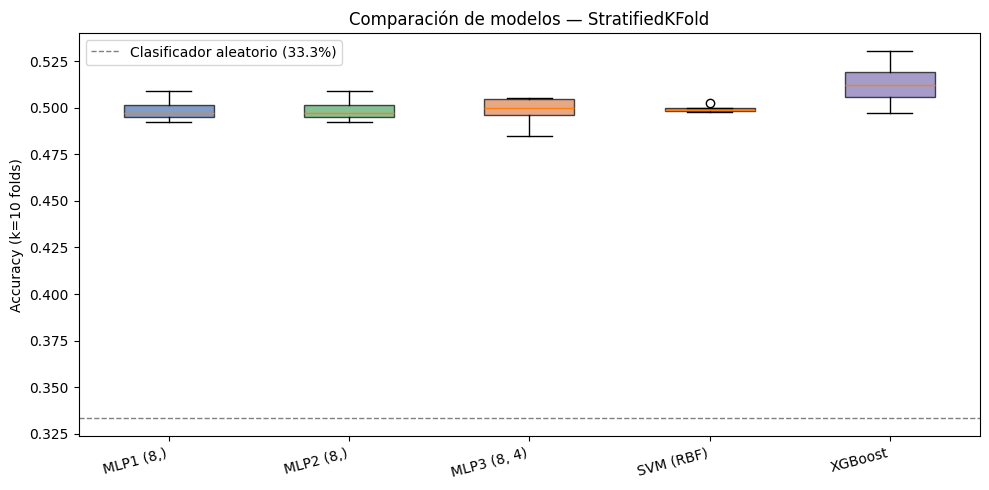

In [63]:
fig, ax = plt.subplots(figsize=(10, 5))

data_plot  = list(resultados_cv.values())
nombres_plot = list(resultados_cv.keys())

bp = ax.boxplot(data_plot, patch_artist=True, notch=False)

colores_modelos = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']
for patch, color in zip(bp['boxes'], colores_modelos):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(nombres_plot) + 1))
ax.set_xticklabels(nombres_plot, rotation=15, ha='right')
ax.set_ylabel('Accuracy (k=10 folds)')
ax.set_title('Comparación de modelos — StratifiedKFold')
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1,
           label='Clasificador aleatorio (33.3%)')
ax.legend()

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

###  **Matriz de Confusión**


Classification report — MLP1 (8,)
              precision    recall  f1-score   support

        REST       0.50      0.97      0.66       984
        MI_L       0.29      0.01      0.02       496
        MI_R       0.34      0.04      0.08       487

    accuracy                           0.50      1967
   macro avg       0.38      0.34      0.25      1967
weighted avg       0.41      0.50      0.36      1967


Classification report — MLP2 (8,)
              precision    recall  f1-score   support

        REST       0.50      0.97      0.66       984
        MI_L       0.29      0.01      0.02       496
        MI_R       0.34      0.04      0.08       487

    accuracy                           0.50      1967
   macro avg       0.38      0.34      0.25      1967
weighted avg       0.41      0.50      0.36      1967


Classification report — MLP3 (8, 4)
              precision    recall  f1-score   support

        REST       0.50      0.95      0.66       984
        MI_L       0.1

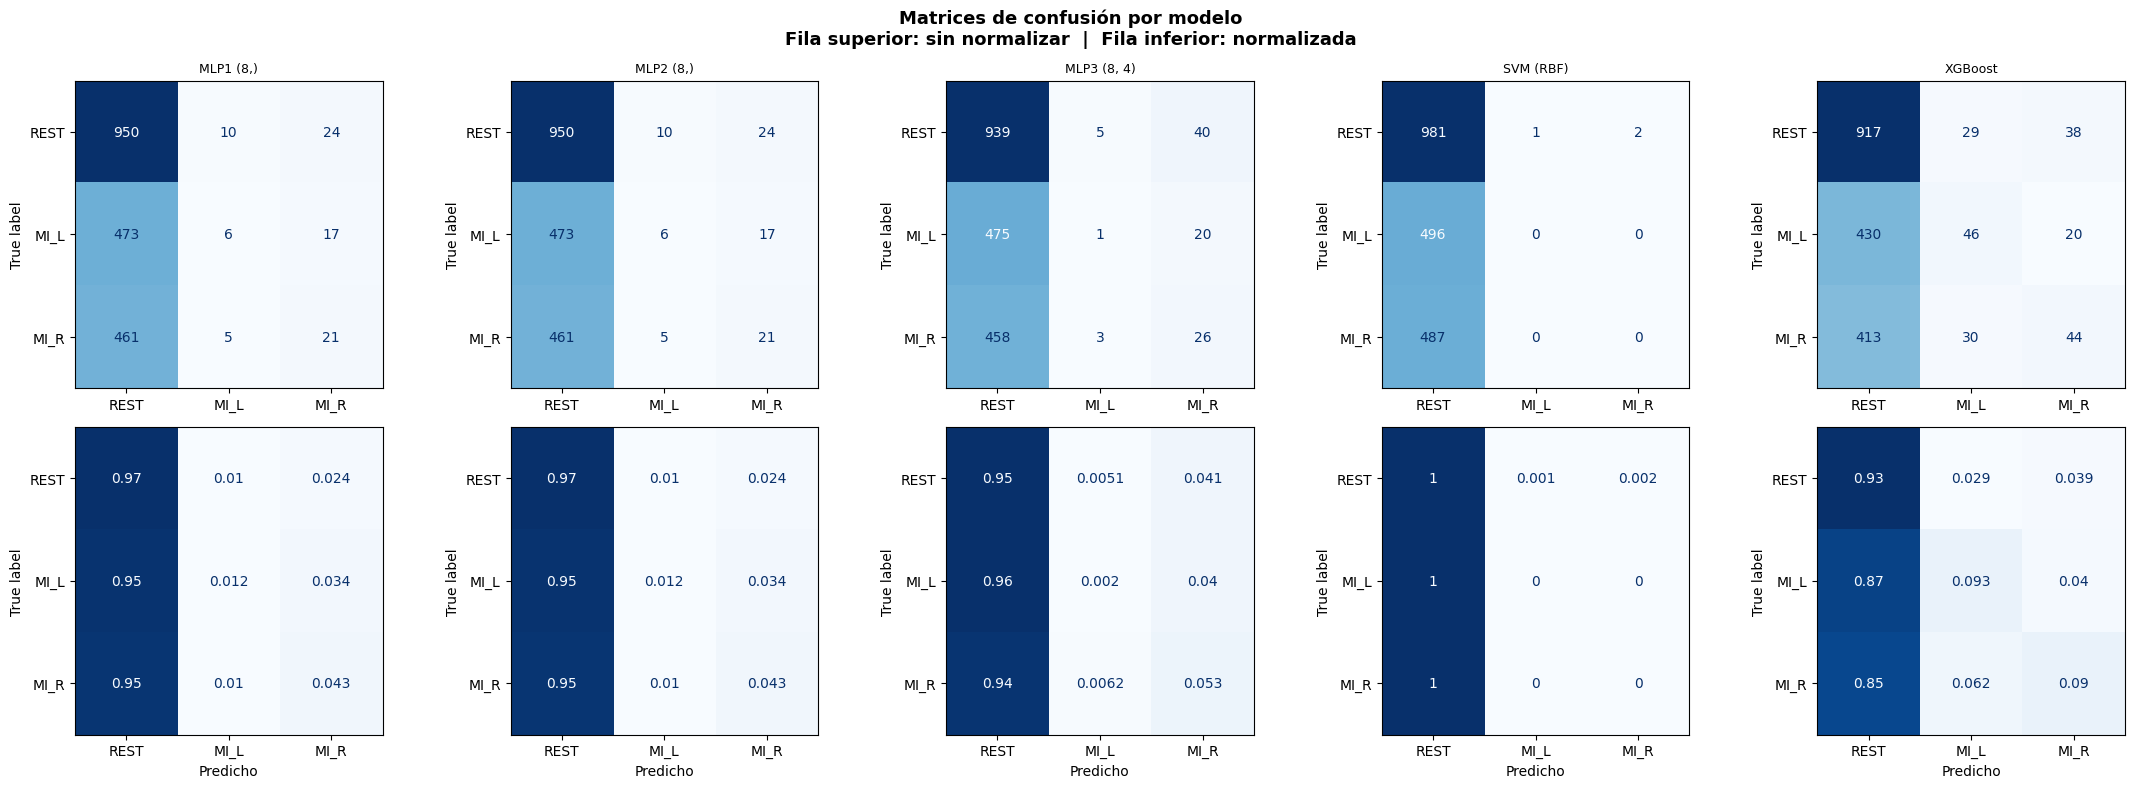

In [65]:
# 7d — Matrices de confusión
# La matriz de confusión muestra cuántas épocas de cada clase real
# fueron clasificadas en cada clase predicha.
# La diagonal principal = clasificaciones correctas.
# Los elementos fuera de la diagonal = errores (falsos positivos/negativos).
#
# Se usa una división fija 80/20 para obtener predicciones concretas
# sobre las que calcular la matriz. El K-Fold del bloque anterior ya
# dio la estimación robusta del desempeño; esta división es solo para
# visualizar los patrones de error.
#
# Por qué normalizar: con clases desbalanceadas la matriz sin normalizar
# puede ser engañosa (muchos aciertos en la clase mayoritaria no implican
# buen clasificador). La versión normalizada muestra la tasa de acierto
# por clase, independientemente del tamaño de cada una.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y      # misma proporción de clases en train y test
)

nombres_clases = ['REST', 'MI_L', 'MI_R']

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Matrices de confusión por modelo\n'
             'Fila superior: sin normalizar  |  Fila inferior: normalizada',
             fontsize=13, fontweight='bold')

for col, (nombre, modelo) in enumerate(modelos.items()):

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # ── Sin normalizar ────────────────────────────────────────────────
    cm_raw = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm_raw, display_labels=nombres_clases).plot(
        ax=axes[0, col], colorbar=False, cmap='Blues'
    )
    axes[0, col].set_title(nombre, fontsize=9)
    axes[0, col].set_xlabel('')

    # ── Normalizada ───────────────────────────────────────────────────
    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm_norm, display_labels=nombres_clases).plot(
        ax=axes[1, col], colorbar=False, cmap='Blues'
    )
    axes[1, col].set_title('')
    axes[1, col].set_xlabel('Predicho')

    # Imprimir classification report para cada modelo
    print(f"\n{'='*50}")
    print(f"Classification report — {nombre}")
    print('='*50)
    print(classification_report(y_test, y_pred,
                                target_names=nombres_clases))

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

#### **c. Consultar cómo funciona, realizar y discutir un ejemplo con los datos del algoritmo máquina de soporte vectorial y extreme gradient boosting**

### **SVM**

La Máquina de Soporte Vectorial (SVM) es un algoritmo supervisado que busca encontrar el hiperplano que maximiza la separación entre clases. Utiliza vectores de soporte, que son las observaciones más cercanas a la frontera de decisión.Busca un hiperplano que maximice la separación entre clases.

### **XGBoost**

Extreme Gradient Boosting (XGBoost) es un algoritmo basado en árboles de decisión ensamblados mediante boosting. Cada árbol corrige los errores cometidos por los anteriores, logrando modelos altamente precisos.Combina múltiples árboles de decisión débiles para construir un clasificador fuerte mediante boosting.

In [68]:
# 7e — Discusión SVM y XGBoost
# SVM ──────────────────────────────────────────────────────────────
# La Máquina de Soporte Vectorial busca el hiperplano que maximiza el
# margen de separación entre clases en el espacio de características.
# Con kernel RBF (Radial Basis Function) proyecta los datos a un espacio
# de mayor dimensión donde las clases pueden ser linealmente separables,
# aunque no lo sean en el espacio original.
#
# Parámetro C: controla el equilibrio entre maximizar el margen y
# minimizar los errores de clasificación en el conjunto de entrenamiento.
#   C pequeño → margen amplio, más errores de entrenamiento (underfitting)
#   C grande  → margen estrecho, menos errores de entrenamiento (riesgo de overfitting)
#
# En BCI, SVM con kernel RBF es uno de los clasificadores más usados
# históricamente por su buen desempeño con pocas muestras de entrenamiento.
# Referencia: Lotte et al., 2018, J. Neural Eng.

# ── XGBoost ──────────────────────────────────────────────────────────
# Extreme Gradient Boosting construye un ensamble de árboles de decisión
# de forma secuencial: cada árbol nuevo se entrena para corregir los
# errores del ensamble anterior (boosting).
# El "gradient" se refiere a que la corrección se guía por el gradiente
# de la función de pérdida, igual que en el descenso de gradiente.
#
# Ventajas sobre MLP y SVM para este problema:
#   - No requiere escalar las features (aunque aquí ya están escaladas)
#   - Maneja naturalmente features irrelevantes (las ignora)
#   - Muy eficiente computacionalmente con datos tabulares
#
# Parámetros usados:
#   n_estimators=100  → número de árboles en el ensamble
#   max_depth=4       → profundidad máxima de cada árbol (controla complejidad)
#   learning_rate=0.1 → cuánto corrige cada árbol nuevo (shrinkage)

# Comparación final de todos los modelos
print("\nRESUMEN FINAL — Accuracy media (K-Fold, k=10)")
print("=" * 45)
for nombre, scores in resultados_cv.items():
    print(f"  {nombre:25s}: {scores.mean():.4f} ± {scores.std():.4f}")


RESUMEN FINAL — Accuracy media (K-Fold, k=10)
  MLP1 (8,)                : 0.4986 ± 0.0052
  MLP2 (8,)                : 0.4986 ± 0.0052
  MLP3 (8, 4)              : 0.4989 ± 0.0063
  SVM (RBF)                : 0.4993 ± 0.0012
  XGBoost                  : 0.5129 ± 0.0097


Se evaluaron tres arquitecturas MLP utilizando validación cruzada estratificada de 10 particiones. Las arquitecturas fueron MLP1 (8 neuronas ocultas), MLP2 (8 neuronas ocultas) y MLP3 (8 y 4 neuronas ocultas). Los tres modelos presentaron desempeños similares, con exactitudes cercanas al 50 %, indicando una capacidad limitada para discriminar las tres clases estudiadas. Las matrices de confusión mostraron que los modelos clasificaron correctamente la mayoría de las épocas de reposo, pero presentaron dificultades para diferenciar las condiciones de imaginación motora izquierda y derecha. Posteriormente se compararon los resultados con un clasificador SVM con kernel RBF y con XGBoost. El SVM tendió a clasificar prácticamente todas las muestras como reposo, mientras que XGBoost obtuvo el mejor desempeño global (51.3 %), logrando identificar una mayor proporción de ejemplos de MI_L y MI_R. Estos resultados sugieren que las características extraídas permiten distinguir parcialmente entre reposo y actividad motora, pero contienen información limitada para separar adecuadamente las dos tareas de imaginación motora. Por ello, futuras mejoras podrían incluir características espaciales como Common Spatial Patterns (CSP), conectividad funcional adicional o enfoques basados en aprendizaje profundo.

### **REFERENCIAS**


[1] Blankertz, B., Tomioka, R., Lemm, S., Kawanabe, M., & Müller, K.-R. (2008). Optimizing spatial filters for robust EEG single-trial analysis. IEEE Signal Processing Magazine, 25(1), 41–56. https://doi.org/10.1109/MSP.2008.4408441

[2] Degirmenci, M., Yuce, Y. K., Perc, M., & Isler, Y. (2023). Statistically significant features improve binary and multiple Motor Imagery task predictions from EEGs. Frontiers in Human Neuroscience, 17, 1223307. https://doi.org/10.3389/fnhum.2023.1223307

[3] Elahi, M. H. et al. (2023). EEG-BCI Features Discrimination between Executed and Imagined Movements Based on FastICA, Hjorth Parameters, and SVM. Mathematics, 11(21), 4409. https://doi.org/10.3390/math11214409

[4] Garcia-Laencina, P. J. et al. (2014). Exploring dimensionality reduction of EEG features in motor imagery task classification. Expert Systems with Applications, 41(10), 4761–4771. https://doi.org/10.1016/j.eswa.2014.02.021

[5] Ji, N., Ma, L., Dong, H., & Zhang, X. (2019). EEG Signals Feature Extraction Based on DWT and EMD Combined with Approximate Entropy. Brain Sciences, 9(8), 201. https://doi.org/10.3390/brainsci9080201

[6] Wang, M. et al. (2023). Motor imagery classification method based on relative wavelet packet entropy brain network and improved lasso. Frontiers in Neuroscience, 17, 1113593. https://doi.org/10.3389/fnins.2023.1113593

[7] M. Atienza, J.L. Cantero-Lorente, R.M. Salas. Valor clínico de la coherencia EEG como índice electrofisiológico de conectividad córticocortical durante el sueño. Rev. Neurol. 2000, 31(5), 442-454. https://doi.org/10.33588/rn.3105.99472
 
[8] MNE Documentation: https://mne.tools

[9] Lotte, F. et al. (2018). A review of classification algorithms for EEG-based brain-computer interfaces: a 10-year update. Journal of Neural Engineering, 15(3), 031005. https://doi.org/10.1088/1741-2552/aab2f2